In [25]:
import os
import sys
import glob
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 50)
pd.set_option('display.max_colwidth', 150)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from math import log
from scipy import stats
sns.set_theme()
try:
    from cellacdc import cca_functions
    from cellacdc import myutils
except FileNotFoundError:
    # Check if user has developer version --> add the Cell_ACDC/cellacdc
    # folder to path and import from thre
    sys.path.insert(0, '../cellacdc/')
    from cellacdc import cca_functions
    from cellacdc import myutils

# ***Import nutrient switch data - original four strains*** 
# ***Import nutrient switch data - Cln3 deletions and MK strains***
# ***Import nutrient switch data - MK strains with deletions*** 
# ***Import steady state data*** 

In [26]:
NS_original_4strains= pd.read_csv(r"Y:\test_dfs_for_final_code\normalnutrientswitch_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
NS_cln3dels_MKoriginals = pd.read_csv(r"Y:\test_dfs_for_final_code\Cln3delsstabs_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
NS_MKstrains_withOriginalDels = pd.read_csv(r"Y:\test_dfs_for_final_code\Cln3stabs_withMutants_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
SS_SCDnSCGE = pd.read_csv(r"Y:\test_dfs_for_final_code\steadystate_analysed_fornutswitch_jupyter_overall_df_with_rel_switch_and_wave_info.csv")

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\2105863768.py:1: DtypeWarning: Columns (371) have mixed types. Specify dtype option on import or set low_memory=False.
  NS_original_4strains= pd.read_csv(r"Y:\test_dfs_for_final_code\normalnutrientswitch_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\2105863768.py:2: DtypeWarning: Columns (371) have mixed types. Specify dtype option on import or set low_memory=False.
  NS_cln3dels_MKoriginals = pd.read_csv(r"Y:\test_dfs_for_final_code\Cln3delsstabs_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\2105863768.py:3: DtypeWarning: Columns (343) have mixed types. Specify dtype option on import or set low_memory=False.
  NS_MKstrains_withOriginalDels = pd.read_csv(r"Y:\test_dfs_for_final_code\Cln3stabs_withMutants_jupyter_overall_df_with_rel_switch_and_wave_info.csv")


# ***update rep for MMY in the additional nutrient switch data*** 

In [27]:
#### because NS_cln3dels_MKoriginals has MMY cells with same rep, pos and Cell_ID as NS_original_4strains, edit rep column for these cells
# NS_MKstrains_withOriginalDels experiments did not have MMY 

NS_cln3dels_MKoriginals.loc[(NS_cln3dels_MKoriginals['strain'] == "MMY") & (NS_cln3dels_MKoriginals['rep'] == 1), 'rep'] = 4
NS_cln3dels_MKoriginals.loc[(NS_cln3dels_MKoriginals['strain'] == "MMY") & (NS_cln3dels_MKoriginals['rep'] == 2), 'rep'] = 5

NS_cln3dels_MKoriginals['f_pos_cell_id'] = NS_cln3dels_MKoriginals.apply(lambda x: f'{x["strain"]}_{x["position"]}_Cell_{x["Cell_ID"]}_Gen_{int(x["generation_num"])}', axis=1)
NS_cln3dels_MKoriginals['rep_str_pos_cell_id'] = NS_cln3dels_MKoriginals.apply(lambda x: f'{x["f_pos_cell_id"]}_Rep_{int(x["rep"])}', axis=1)
NS_cln3dels_MKoriginals = NS_cln3dels_MKoriginals.drop(['f_pos_cell_id'], axis=1)
NS_cln3dels_MKoriginals = NS_cln3dels_MKoriginals.rename(columns={"rep_str_pos_cell_id": "f_pos_cell_id"})


# ***because acdc output columns changed over the years, find differences between column names of different dfs and edit them*** 

In [28]:
NS_MKstrains_withOriginalDels.drop(columns =['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel',  'num_objects', 'num_objects_rel',
       'will_divide', 'will_divide_rel'], inplace = True)
#print(NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns))

In [29]:
NS_cln3dels_MKoriginals.drop(columns =['bbox', 'bbox_rel', 'centroid', 'centroid_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inertia_tensor_eigvals_rel',
       'inertia_tensor_rel', 'label', 'label_rel', 'local_centroid',
       'local_centroid_rel', 'moments', 'moments_central',
       'moments_central_rel', 'moments_normalized', 'moments_normalized_rel',
       'moments_rel', 'time_hours', 'time_hours_rel', 'time_minutes',
       'time_minutes_rel'], inplace = True)

In [30]:
NS_MKstrains_withOriginalDels.drop(columns =['bbox', 'bbox_rel', 'centroid', 'centroid_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inertia_tensor_eigvals_rel',
       'inertia_tensor_rel', 'label', 'label_rel', 'local_centroid',
       'local_centroid_rel', 'moments', 'moments_central',
       'moments_central_rel', 'moments_normalized', 'moments_normalized_rel',
       'moments_rel', 'time_hours', 'time_hours_rel', 'time_minutes',
       'time_minutes_rel'], inplace = True)

In [31]:
NS_MKstrains_withOriginalDels.columns.difference(NS_original_4strains.columns)

Index(['does_cell_die_in_this_phase', 'vol_added_since_prev_frame_fl'], dtype='object')

In [32]:
NS_original_4strains.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel', 'bbox',
       'bbox_rel', 'centroid', 'centroid_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inert

In [33]:
NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns)

Index(['does_cell_die_in_this_phase'], dtype='object')

In [34]:
NS_original_4strains = NS_original_4strains.rename(columns={"vol_added_since_last_frame": "vol_added_since_prev_frame_fl"})
SS_SCDnSCGE = SS_SCDnSCGE.rename(columns={"Strain": "strain"})

In [35]:
NS_cln3dels_MKoriginals.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'num_objects',
       'num_objects_rel', 'will_divide', 'will_divide_rel'],
      dtype='object')

# ***Add 'does_cell_die_in_this_phase' column to the datasets that don't have it*** 

In [36]:
import warnings

with warnings.catch_warnings(record=True):
    list_for_joining = []
    for rep in NS_original_4strains['rep'].unique():
        rep_df = NS_original_4strains[NS_original_4strains['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df = rep_df[rep_df['strain'] == strain]
            for pos in (strain_df['position']).unique():
                pos_df = strain_df[strain_df["position"] == pos]
                pos_max_frame = pos_df['frame_i'].max()
                pos_min_frame = pos_df['frame_i'].min()
                for cell in (pos_df['Cell_ID']).unique():
                    cell_df = pos_df[pos_df["Cell_ID"] == cell]
                    for cycle in (cell_df['generation_num']).unique(): 
                        cycle_df = cell_df[cell_df["generation_num"] == cycle]
                        cycle_df = cycle_df.sort_values(by = 'frame_i')
                        for phase in (cycle_df['cell_cycle_stage'].unique()):
                            phase_df = cycle_df[cycle_df['cell_cycle_stage'] == phase]
                            if ((phase_df['frame_i'].min()) > pos_min_frame) & ((phase_df['frame_i'].max()) < pos_max_frame):
                                phase_df['complete_phase'] = 1
                                phase_df['does_cell_die_in_this_phase'] = 0
                            if sum(phase_df['is_cell_dead']) > 0:
                                phase_df['complete_phase'] = 0
                                phase_df['does_cell_die_in_this_phase'] = 1
                            else:
                                phase_df['does_cell_die_in_this_phase'] = 0
                            list_for_joining.append(phase_df)
    NS_original_4strains = pd.concat(list_for_joining)   

In [37]:
import warnings

with warnings.catch_warnings(record=True):
    list_for_joining = []
    for rep in NS_cln3dels_MKoriginals['rep'].unique():
        rep_df = NS_cln3dels_MKoriginals[NS_cln3dels_MKoriginals['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df = rep_df[rep_df['strain'] == strain]
            for pos in (strain_df['position']).unique():
                pos_df = strain_df[strain_df["position"] == pos]
                pos_max_frame = pos_df['frame_i'].max()
                pos_min_frame = pos_df['frame_i'].min()
                for cell in (pos_df['Cell_ID']).unique():
                    cell_df = pos_df[pos_df["Cell_ID"] == cell]
                    for cycle in (cell_df['generation_num']).unique(): 
                        cycle_df = cell_df[cell_df["generation_num"] == cycle]
                        cycle_df = cycle_df.sort_values(by = 'frame_i')
                        for phase in (cycle_df['cell_cycle_stage'].unique()):
                            phase_df = cycle_df[cycle_df['cell_cycle_stage'] == phase]
                            if ((phase_df['frame_i'].min()) > pos_min_frame) & ((phase_df['frame_i'].max()) < pos_max_frame):
                                phase_df['complete_phase'] = 1
                                phase_df['does_cell_die_in_this_phase'] = 0
                            if sum(phase_df['is_cell_dead']) > 0:
                                phase_df['complete_phase'] = 0
                                phase_df['does_cell_die_in_this_phase'] = 1
                            else:
                                phase_df['does_cell_die_in_this_phase'] = 0
                            list_for_joining.append(phase_df)
    NS_cln3dels_MKoriginals = pd.concat(list_for_joining)   

In [38]:
NS_MKstrains_withOriginalDels.columns.difference(NS_original_4strains.columns)

Index([], dtype='object')

In [39]:
NS_original_4strains.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel', 'bbox',
       'bbox_rel', 'centroid', 'centroid_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inert

In [40]:
NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns)

Index([], dtype='object')

In [41]:
NS_cln3dels_MKoriginals.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'num_objects',
       'num_objects_rel', 'will_divide', 'will_divide_rel'],
      dtype='object')

# ***Drop columns not needed for analysis*** 

In [42]:
#drop columns we don't need
cols_to_be_dropped = ['Dia_Ph3_mean', 'Dia_Ph3_sum', 'Dia_Ph3_amount_autoBkgr', 'Dia_Ph3_amount_dataPrepBkgr', 'Dia_Ph3_concentration_autoBkgr_from_vol_vox',
'Dia_Ph3_concentration_dataPrepBkgr_from_vol_vox', 'Dia_Ph3_concentration_autoBkgr_from_vol_fl', 'Dia_Ph3_concentration_dataPrepBkgr_from_vol_fl', 
'Dia_Ph3_median', 'Dia_Ph3_min', 'Dia_Ph3_max', 'Dia_Ph3_q25', 'Dia_Ph3_q75', 'Dia_Ph3_q05', 'Dia_Ph3_q95', 'Dia_Ph3_autoBkgr_bkgrVal_median', 
'Dia_Ph3_autoBkgr_bkgrVal_mean', 'Dia_Ph3_autoBkgr_bkgrVal_q75', 'Dia_Ph3_autoBkgr_bkgrVal_q25', 'Dia_Ph3_autoBkgr_bkgrVal_q95', 'Dia_Ph3_autoBkgr_bkgrVal_q05', 
'Dia_Ph3_dataPrepBkgr_bkgrVal_median', 'Dia_Ph3_dataPrepBkgr_bkgrVal_mean', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q75', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q25', 
'Dia_Ph3_dataPrepBkgr_bkgrVal_q95', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q05', 'Dia_Ph3_CV', 'major_axis_length_gui', 'minor_axis_length_gui', 'inertia_tensor_eigvals-0', 
'inertia_tensor_eigvals-1', 'equivalent_diameter', 'moments-0-0', 'moments-0-1', 'moments-0-2', 'moments-0-3', 'moments-1-0', 'moments-1-1', 'moments-1-2',
'moments-1-3', 'moments-2-0', 'moments-2-1', 'moments-2-2', 'moments-2-3', 'moments-3-0', 'moments-3-1', 'moments-3-2', 'moments-3-3', 'area_gui', 'solidity_gui', 
'extent', 'inertia_tensor-0-0', 'inertia_tensor-0-1', 'inertia_tensor-1-0', 'inertia_tensor-1-1', 'filled_area_gui', 'centroid-0', 'centroid-1', 'bbox_area',
'local_centroid-0', 'local_centroid-1', 'convex_area_gui', 'euler_number', 'moments_normalized-0-0', 'moments_normalized-0-1', 'moments_normalized-0-2',
'moments_normalized-0-3', 'moments_normalized-1-0', 'moments_normalized-1-1', 'moments_normalized-1-2', 'moments_normalized-1-3', 'moments_normalized-2-0',
'moments_normalized-2-1', 'moments_normalized-2-2', 'moments_normalized-2-3', 'moments_normalized-3-0', 'moments_normalized-3-1', 'moments_normalized-3-2',
'moments_normalized-3-3', 'moments_central-0-0', 'moments_central-0-1', 'moments_central-0-2', 'moments_central-0-3', 'moments_central-1-0', 'moments_central-1-1',
'moments_central-1-2', 'moments_central-1-3', 'moments_central-2-0', 'moments_central-2-1', 'moments_central-2-2', 'moments_central-2-3', 'moments_central-3-0',
'moments_central-3-1', 'moments_central-3-2', 'moments_central-3-3', 'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3', 'area', 'convex_area', 'filled_area', 'major_axis_length','minor_axis_length', 'orientation', 'perimeter', 'centroid_y', 'centroid_x', 'solidity','velocity_pixel', 'velocity_um','Dia_Ph3_mean_rel', 'Dia_Ph3_sum_rel','Dia_Ph3_amount_autoBkgr_rel', 'Dia_Ph3_amount_dataPrepBkgr_rel', 'Dia_Ph3_concentration_autoBkgr_from_vol_vox_rel', 
'Dia_Ph3_concentration_dataPrepBkgr_from_vol_vox_rel', 'Dia_Ph3_concentration_autoBkgr_from_vol_fl_rel', 'Dia_Ph3_concentration_dataPrepBkgr_from_vol_fl_rel', 
'Dia_Ph3_median_rel', 'Dia_Ph3_min_rel', 'Dia_Ph3_max_rel', 'Dia_Ph3_q25_rel', 'Dia_Ph3_q75_rel', 'Dia_Ph3_q05_rel', 'Dia_Ph3_q95_rel',
'Dia_Ph3_autoBkgr_bkgrVal_median_rel', 'Dia_Ph3_autoBkgr_bkgrVal_mean_rel', 'Dia_Ph3_autoBkgr_bkgrVal_q75_rel', 'Dia_Ph3_autoBkgr_bkgrVal_q25_rel',
'Dia_Ph3_autoBkgr_bkgrVal_q95_rel', 'Dia_Ph3_autoBkgr_bkgrVal_q05_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_median_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_mean_rel',
'Dia_Ph3_dataPrepBkgr_bkgrVal_q75_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q25_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q95_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q05_rel', 
'Dia_Ph3_CV_rel', 'major_axis_length_gui_rel', 'minor_axis_length_gui_rel', 'inertia_tensor_eigvals-0_rel', 'inertia_tensor_eigvals-1_rel', 'equivalent_diameter_rel','moments-0-0_rel', 'moments-0-1_rel', 'moments-0-2_rel', 'moments-0-3_rel', 'moments-1-0_rel', 'moments-1-1_rel', 'moments-1-2_rel', 'moments-1-3_rel', 'moments-2-0_rel', 'moments-2-1_rel', 'moments-2-2_rel', 'moments-2-3_rel', 'moments-3-0_rel', 'moments-3-1_rel', 'moments-3-2_rel', 'moments-3-3_rel','area_gui_rel', 'solidity_gui_rel', 'extent_rel', 'inertia_tensor-0-0_rel', 'inertia_tensor-0-1_rel', 'inertia_tensor-1-0_rel', 'inertia_tensor-1-1_rel','filled_area_gui_rel', 'centroid-0_rel', 'centroid-1_rel', 'bbox_area_rel', 'local_centroid-0_rel', 'local_centroid-1_rel', 'convex_area_gui_rel', 'euler_number_rel', 'moments_normalized-0-0_rel', 'moments_normalized-0-1_rel', 'moments_normalized-0-2_rel', 'moments_normalized-0-3_rel', 
'moments_normalized-1-0_rel', 'moments_normalized-1-1_rel', 'moments_normalized-1-2_rel', 'moments_normalized-1-3_rel', 'moments_normalized-2-0_rel',
'moments_normalized-2-1_rel', 'moments_normalized-2-2_rel', 'moments_normalized-2-3_rel', 'moments_normalized-3-0_rel', 'moments_normalized-3-1_rel', 
'moments_normalized-3-2_rel', 'moments_normalized-3-3_rel', 'moments_central-0-0_rel', 'moments_central-0-1_rel', 'moments_central-0-2_rel', 
'moments_central-0-3_rel', 'moments_central-1-0_rel', 'moments_central-1-1_rel', 'moments_central-1-2_rel', 'moments_central-1-3_rel', 'moments_central-2-0_rel',
'moments_central-2-1_rel', 'moments_central-2-2_rel', 'moments_central-2-3_rel', 'moments_central-3-0_rel', 'moments_central-3-1_rel', 'moments_central-3-2_rel',
'moments_central-3-3_rel', 'bbox-0_rel', 'bbox-1_rel', 'bbox-2_rel', 'bbox-3_rel', 'area_rel', 'convex_area_rel', 'filled_area_rel', 'major_axis_length_rel', 
'minor_axis_length_rel', 'orientation_rel', 'perimeter_rel', 'centroid_y_rel', 'centroid_x_rel', 'solidity_rel', 'velocity_pixel_rel', 'velocity_um_rel',
'phase_Dia_Ph3_amount_at_beginning', 'phase_Dia_Ph3_mean_at_beginning', 'phase_Dia_Ph3_concentration_at_beginning', 'phase_Dia_Ph3_concentration_at_end', 
'phase_Dia_Ph3_combined_amount_at_beginning', 'phase_Dia_Ph3_combined_amount_at_end', 'Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
'Dia_Ph3_manualBkgr_bkgrVal_mean','Dia_Ph3_manualBkgr_bkgrVal_mean_rel','Dia_Ph3_manualBkgr_bkgrVal_median','Dia_Ph3_manualBkgr_bkgrVal_median_rel',
'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel','Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel','Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel', 'bbox','bbox_rel', 'centroid', 'centroid_rel','daughter_disappears_before_division',
'daughter_disappears_before_division_rel', 'disappears_before_division','disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'inertia_tensor','inertia_tensor_eigvals', 'inertia_tensor_eigvals_rel','inertia_tensor_rel', 'label', 'label_rel', 'local_centroid','local_centroid_rel', 'moments', 'moments_central','moments_central_rel','moments_normalized','moments_normalized_rel','moments_rel', 'num_objects', 'num_objects_rel', 'time_hours','time_hours_rel', 'time_minutes', 'time_minutes_rel', 'will_divide','will_divide_rel']

NS_original_4strains.drop(columns=[col for col in NS_original_4strains if col in cols_to_be_dropped], inplace=True)
NS_cln3dels_MKoriginals.drop(columns=[col for col in NS_cln3dels_MKoriginals if col in cols_to_be_dropped], inplace=True)
NS_MKstrains_withOriginalDels.drop(columns=[col for col in NS_MKstrains_withOriginalDels if col in cols_to_be_dropped], inplace=True)
SS_SCDnSCGE.drop(columns=[col for col in SS_SCDnSCGE if col in cols_to_be_dropped], inplace=True)



In [43]:
print(NS_original_4strains.shape)
print(NS_cln3dels_MKoriginals.shape)
print(NS_MKstrains_withOriginalDels.shape)
print(SS_SCDnSCGE.shape)

NS_original_4strains['experiment_type'] = "nutrient_switch"
NS_cln3dels_MKoriginals['experiment_type'] = "nutrient_switch"
NS_MKstrains_withOriginalDels['experiment_type'] = "nutrient_switch"
SS_SCDnSCGE['experiment_type'] = "steady state"


(482563, 114)
(366669, 114)
(388955, 114)
(366878, 61)


In [44]:
NS_MKstrains_withOriginalDels.columns.difference(NS_original_4strains.columns)

Index([], dtype='object')

In [45]:
NS_original_4strains.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index([], dtype='object')

In [46]:
NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns)

Index([], dtype='object')

In [47]:
NS_cln3dels_MKoriginals.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index([], dtype='object')

# ***All the nutrient-switch dfs have the same columns now. Steady-state dfs were dataprepped with a different script before acdc downstream notebook was published, so they have very different columns.*** 

In [48]:
SS_SCDnSCGE = SS_SCDnSCGE.rename(columns={"date": "rep", "Position": "position"})
SS_SCD = SS_SCDnSCGE[SS_SCDnSCGE['growthmedium'] == "SCD"]
SS_SCGE = SS_SCDnSCGE[SS_SCDnSCGE['growthmedium'] == "SCGE"]

# ***Check strain names and make them uniform between dfs*** 

In [49]:
print(NS_original_4strains.strain.unique())
print(NS_cln3dels_MKoriginals.strain.unique())
print(NS_MKstrains_withOriginalDels.strain.unique())
print(SS_SCDnSCGE.strain.unique())
NS_MKstrains_withOriginalDels['strain'] = np.where(NS_MKstrains_withOriginalDels['strain'] == "MK40", "MK_40", NS_MKstrains_withOriginalDels['strain'])
print(NS_original_4strains.strain.unique())
print(NS_cln3dels_MKoriginals.strain.unique())
print(NS_MKstrains_withOriginalDels.strain.unique())
print(SS_SCDnSCGE.strain.unique())

['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD']
['MMY' 'CLN3DEL' 'CLN3_WHI5_DD' 'CLN3_WHI5_BCK2_TD' 'MK_40' 'MK_41'
 'MK_44']
['MK40' 'YCY027_1_bck2delMK40bg' 'YCY031_4_whi5delMK40bg'
 'YCY034_1_doubledelMK40bg' 'MK_44' 'YCY029_3_bck2delMK44bg'
 'YCY033_2_whi5delMK44bg' 'YCY036_1_doubledelMK44bg']
['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD' 'WHI5_CCR4_DD' 'CCR4DEL']
['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD']
['MMY' 'CLN3DEL' 'CLN3_WHI5_DD' 'CLN3_WHI5_BCK2_TD' 'MK_40' 'MK_41'
 'MK_44']
['MK_40' 'YCY027_1_bck2delMK40bg' 'YCY031_4_whi5delMK40bg'
 'YCY034_1_doubledelMK40bg' 'MK_44' 'YCY029_3_bck2delMK44bg'
 'YCY033_2_whi5delMK44bg' 'YCY036_1_doubledelMK44bg']
['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD' 'WHI5_CCR4_DD' 'CCR4DEL']


# ***Concatenate all nutrient switch dfs into one*** 

In [50]:
overall_df_with_rel_and_switch_info = pd.concat([NS_original_4strains, NS_cln3dels_MKoriginals, NS_MKstrains_withOriginalDels]).reset_index(drop = True)

# print(NS_original_4strains.shape)
# print(NS_cln3dels_MKoriginals.shape)
# print(NS_MKstrains_withOriginalDels.shape)
# overall_df_with_rel_and_switch_info.shape 

(482563, 115)
(366669, 115)
(388955, 115)


(1238187, 115)

# ***Fig 4B: Switchers only - phase lengths - selected strains*** 

In [51]:
# display(SS_SCDnSCGE.complete_phase.unique())
# display(SS_SCDnSCGE.complete_cycle.unique())
# display(overall_df_with_rel_and_switch_info.complete_phase.unique())
# display(overall_df_with_rel_and_switch_info.complete_cycle.unique())

In [52]:
############################### steady state use old dataprep ############################################################################
steady_state_df = SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == True)]

steady_state_plotting_df = steady_state_df[["f_pos_cell_id","time_in_stage_mins", "growthmedium", "strain", "Daughterhood_binary",
                                            "complete_phase", "sys_vol_at_frame_inc_G1_cells", "Birth_or_div_vol_fl", "frame_i", "lenG1_mins", "cell_cycle_stage"]]

# getting only the last frame of both cell-cycle stages for every cell
unique_f_pos_cell_id = []
for fposid in ((steady_state_plotting_df['f_pos_cell_id']).unique()):
    fposid_df = steady_state_plotting_df[steady_state_plotting_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id.append(phase_df.iloc[-1:])
unique_steady_state_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)

unique_steady_state_plotting_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df['strain'] == "MMY")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "BCK2DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5_BCK2_DD")
                                                                 ]

palette ={"MMY": "grey", "WHI5DEL": "teal", "BCK2DEL": "mediumvioletred", "WHI5_BCK2_DD": "darkblue"}

############################### nutrient switch switch cycle plotting df prep ############################################################################
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

complete_switch_cycles = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            ]

# getting only the first frame of both cell-cycle stages for every cell
unique_f_pos_cell_id_phase = []
for fposid in ((complete_switch_cycles['f_pos_cell_id']).unique()):
    fposid_df = complete_switch_cycles[complete_switch_cycles['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id_phase.append(phase_df.iloc[:1])
unique_phase_first_frame_df = pd.concat(unique_f_pos_cell_id_phase).reset_index(drop = True)

unique_phase_first_frame_df['phase_length_mins'] = unique_phase_first_frame_df['phase_length']*3
display(unique_phase_first_frame_df['f_pos_cell_id'].loc[unique_phase_first_frame_df['phase_length_mins'] > 1250])

############################### nutrient switch cycle after switch cycle plotting df prep ############################################################################


complete_cycle_after_switch_cycle = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cell_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1) |
                                                               (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0")) 
                                                            ]

# getting only the first frame of both cell-cycle stages for every cell
unique_f_pos_cell_id_phase_2 = []
for fposid in ((complete_cycle_after_switch_cycle['f_pos_cell_id']).unique()):
    fposid_df = complete_cycle_after_switch_cycle[complete_cycle_after_switch_cycle['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id_phase_2.append(phase_df.iloc[:1])
unique_phase_first_frame_df_2 = pd.concat(unique_f_pos_cell_id_phase_2).reset_index(drop = True)

unique_phase_first_frame_df_2['phase_length_mins'] = unique_phase_first_frame_df_2['phase_length']*3




Series([], Name: f_pos_cell_id, dtype: object)

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\683533813.py:154: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)


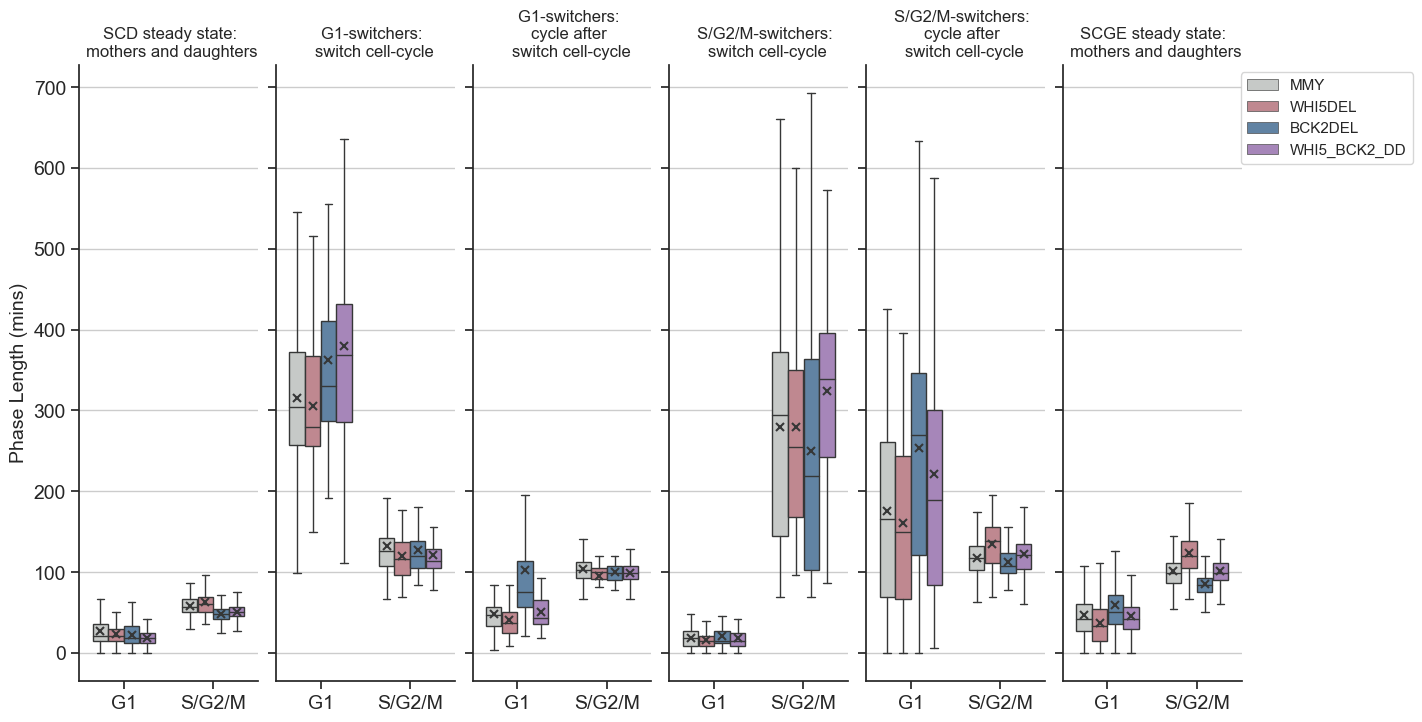

In [53]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2, ax3, ax4, ax5, ax6)) = plt.subplots(nrows=1, ncols=6, sharex= False, sharey= True, figsize=(15, 8) )
S = sns.boxplot(data=(unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"]), 
                showmeans = True,
                x= "cell_cycle_stage", 
                y="time_in_stage_mins", 
                hue = "strain", 
                ax = ax1, 
                showfliers = False, 
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax1.set_title("SCD steady state: \nmothers and daughters", fontsize = 12, x=0.52)
ax1.set_ylabel("Phase Length (mins)", fontsize = 14)

S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"]),
                order=['G1','S'],
                showmeans = True,
                x= "cell_cycle_stage",
                y="time_in_stage_mins",
                hue = "strain",
                ax = ax6,
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax6.set_title("SCGE steady state: \nmothers and daughters", fontsize = 12, x=0.52)
ax6.set_ylabel("")

S = sns.boxplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]),
                showmeans = True,
                x= "cell_cycle_stage",
                y="phase_length_mins",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax2, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax2.set_title("G1-switchers: \nswitch cell-cycle", fontsize = 12, x=0.55)
ax2.set_ylabel("")

S = sns.boxplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]),
                showmeans = True,
                x= "cell_cycle_stage",
                y="phase_length_mins",
                ax = ax4,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax4, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax4.set_title("S/G2/M-switchers: \nswitch cell-cycle", fontsize = 12, x=0.55)
ax4.set_ylabel("") 

S = sns.boxplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True]),
                showmeans = True,
                x= "cell_cycle_stage",
                y="phase_length_mins",
                ax = ax3,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True]), 
#                         x= "cell_cycle_stage", y="phase_length_mins", ax = ax3, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax3.set_title("G1-switchers: \ncycle after \nswitch cell-cycle", fontsize = 12, x=0.55)
ax3.set_ylabel("")

S = sns.boxplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False]),
                showmeans = True,
                x= "cell_cycle_stage",
                y="phase_length_mins",
                ax = ax5,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False]), 
#                         x= "cell_cycle_stage", y="phase_length_mins", ax = ax5, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax5.set_title("S/G2/M-switchers: \ncycle after \nswitch cell-cycle", fontsize = 12, x=0.55)
ax5.set_ylabel("")

#display(unique_phase_first_frame_df[(unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False) 
                                   # & (unique_phase_first_frame_df['strain'] == "WHI5DEL")
                                   # & (unique_phase_first_frame_df['phase_length_mins'] <400)].drop(columns = ['directory']))

ax1.legend([],[], frameon=False)
ax2.legend([],[], frameon=False)
ax3.legend([],[], frameon=False)
ax4.legend([],[], frameon=False)
ax5.legend([],[], frameon=False)
ax6.legend(loc='upper right', bbox_to_anchor=(2, 1))

xtix = ['G1', 'S/G2/M']
ax1.set_xticklabels(xtix, fontsize = 14)
ax2.set_xticklabels(xtix, fontsize = 14)
ax3.set_xticklabels(xtix, fontsize = 14)
ax4.set_xticklabels(xtix, fontsize = 14)
ax5.set_xticklabels(xtix, fontsize = 14)
ax6.set_xticklabels(xtix, fontsize = 14)

ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)


ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")
ax4.set_xlabel("")
ax5.set_xlabel("")
ax6.set_xlabel("")
plt.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)
sns.despine(ax = ax5)
sns.despine(ax = ax6)

#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig3\Panel2_switchers_G1_analysis.svg")
plt.show()

# ***Fig 4C: Switchers only - vol at G1 end - selected strains*** 

In [54]:
############################### steady state use old dataprep ############################################################################
steady_state_df = SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == True) 
                              #& (SS_SCDnSCGE['cell_cycle_stage'] == "G1")
                             ]

steady_state_plotting_df = steady_state_df[["f_pos_cell_id","time_in_stage_mins", "growthmedium", "strain", "Daughterhood_binary",
                                            "complete_phase", "sys_vol_at_frame_inc_G1_cells", "Birth_or_div_vol_fl", "frame_i", "lenG1_mins", "cell_cycle_stage"]]

# getting only the last frame of both cell-cycle stages for every cell
unique_f_pos_cell_id = []
for fposid in ((steady_state_plotting_df['f_pos_cell_id']).unique()):
    fposid_df = steady_state_plotting_df[steady_state_plotting_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id.append(phase_df.iloc[-1:])
unique_steady_state_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)

unique_steady_state_plotting_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df['strain'] == "MMY")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "BCK2DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5_BCK2_DD")
                                                                 ]


############################### nutrient switch switch cycle plotting df prep ############################################################################
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

complete_switch_cycles = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            #& (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                            ]

# getting only the first frame of both cell-cycle stages for every cell
unique_f_pos_cell_id_phase = []
for fposid in ((complete_switch_cycles['f_pos_cell_id']).unique()):
    fposid_df = complete_switch_cycles[complete_switch_cycles['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id_phase.append(phase_df.iloc[:1])
unique_phase_first_frame_df = pd.concat(unique_f_pos_cell_id_phase).reset_index(drop = True)

unique_phase_first_frame_df['phase_length_mins'] = unique_phase_first_frame_df['phase_length']*3
display(unique_phase_first_frame_df['f_pos_cell_id'].loc[unique_phase_first_frame_df['phase_length_mins'] > 1250])

############################### nutrient switch cycle after switch cycle plotting df prep ############################################################################


complete_cycle_after_switch_cycle = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cell_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1) |
                                                               (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0")) 
                                                            #& (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                            ]

# getting only the first frame of both cell-cycle stages for every cell
unique_f_pos_cell_id_phase_2 = []
for fposid in ((complete_cycle_after_switch_cycle['f_pos_cell_id']).unique()):
    fposid_df = complete_cycle_after_switch_cycle[complete_cycle_after_switch_cycle['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id_phase_2.append(phase_df.iloc[:1])
unique_phase_first_frame_df_2 = pd.concat(unique_f_pos_cell_id_phase_2).reset_index(drop = True)

unique_phase_first_frame_df_2['phase_length_mins'] = unique_phase_first_frame_df_2['phase_length']*3




Series([], Name: f_pos_cell_id, dtype: object)

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\1757621977.py:169: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)


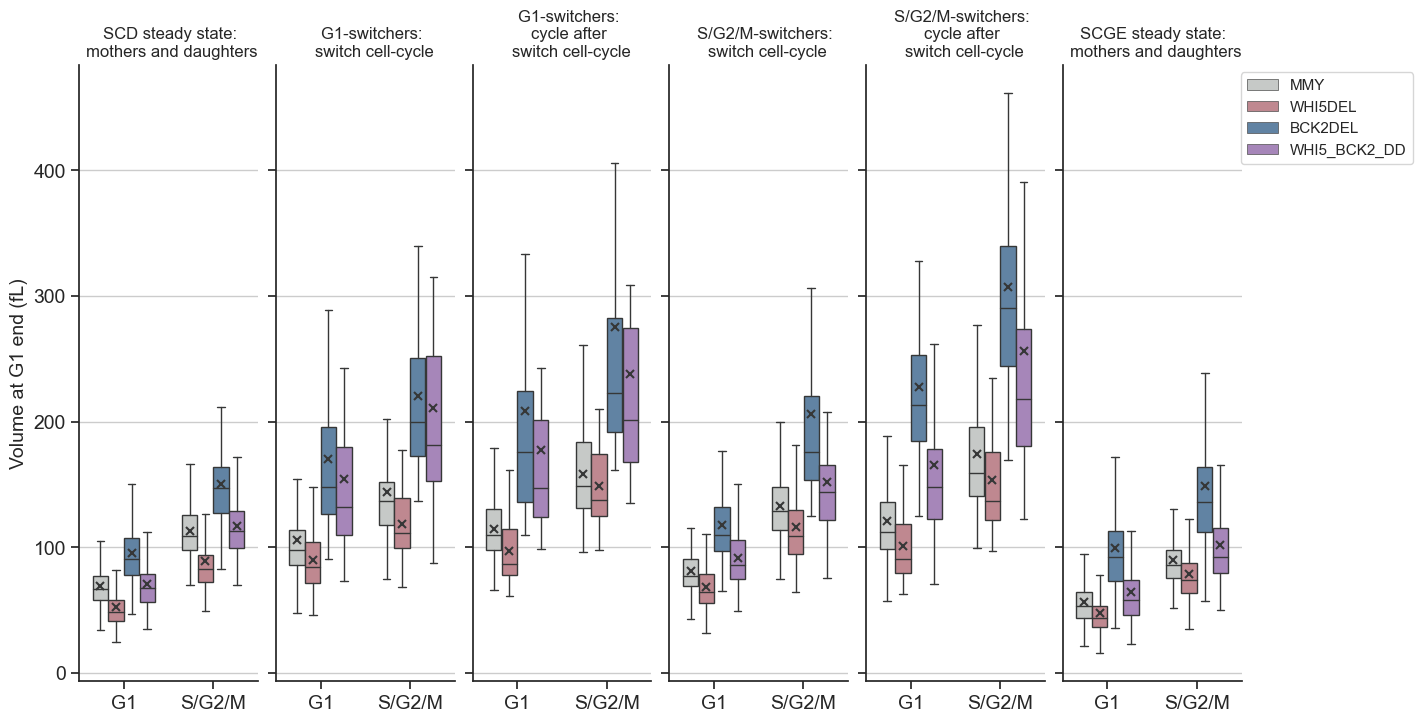

In [56]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2, ax3, ax4, ax5, ax6)) = plt.subplots(nrows=1, ncols=6, sharex= False, sharey= True, figsize=(15, 8) )

S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"]), 
                showmeans = True,
                x= "cell_cycle_stage", 
                order = ['G1', 'S'],
                y="sys_vol_at_frame_inc_G1_cells", 
                hue = "strain", 
                ax = ax1, 
                showfliers = False, 
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax1.set_title("SCD steady state: \nmothers and daughters", fontsize = 12, x=0.52)
ax1.set_ylabel("Volume at G1 end (fL)", fontsize = 14)

S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"]),
                # order=['G1','S'],
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="sys_vol_at_frame_inc_G1_cells",
                hue = "strain",
                ax = ax6,
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax6.set_title("SCGE steady state: \nmothers and daughters", fontsize = 12, x=0.52)
ax6.set_ylabel("")

S = sns.boxplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]),
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="phase_combined_volume_at_end",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_volume_at_end", ax = ax2, hue = "strain", color = "black", 
#                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
#                        dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax2.set_title("G1-switchers: \nswitch cell-cycle", fontsize = 12, x=0.55)
ax2.set_ylabel("")

S = sns.boxplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]),
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="phase_combined_volume_at_end",
                ax = ax4,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]), 
#                        x= "cell_cycle_stage", y="phase_volume_at_end", ax = ax4, hue = "strain", color = "black", 
#                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
#                        dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax4.set_title("S/G2/M-switchers: \nswitch cell-cycle", fontsize = 12, x=0.55)
ax4.set_ylabel("") 

S = sns.boxplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True]),
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="phase_combined_volume_at_end",
                ax = ax3,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_volume_at_end", ax = ax3, hue = "strain", color = "black", 
#                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
#                        dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax3.set_title("G1-switchers: \ncycle after \nswitch cell-cycle", fontsize = 12, x=0.55)
ax3.set_ylabel("")

S = sns.boxplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False]),
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="phase_combined_volume_at_end",
                ax = ax5,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False]), 
#                        x= "cell_cycle_stage", y="phase_volume_at_end", ax = ax5, hue = "strain", color = "black", 
#                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
#                        dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax5.set_title("S/G2/M-switchers: \ncycle after \nswitch cell-cycle", fontsize = 12, x=0.55)
ax5.set_ylabel("")

#display(unique_phase_first_frame_df[(unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False) 
                                   # & (unique_phase_first_frame_df['strain'] == "WHI5DEL")
                                   # & (unique_phase_first_frame_df['phase_length_mins'] <400)].drop(columns = ['directory']))

ax1.legend([],[], frameon=False)
ax2.legend([],[], frameon=False)
ax3.legend([],[], frameon=False)
ax4.legend([],[], frameon=False)
ax5.legend([],[], frameon=False)
ax6.legend(loc='upper right', bbox_to_anchor=(2, 1))

xtix = ['G1', 'S/G2/M']
ax1.set_xticklabels(xtix, fontsize = 14)
ax2.set_xticklabels(xtix, fontsize = 14)
ax3.set_xticklabels(xtix, fontsize = 14)
ax4.set_xticklabels(xtix, fontsize = 14)
ax5.set_xticklabels(xtix, fontsize = 14)
ax6.set_xticklabels(xtix, fontsize = 14)
#ax1.set_ylim(0,450)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)


ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")
ax4.set_xlabel("")
ax5.set_xlabel("")
ax6.set_xlabel("")
plt.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)
sns.despine(ax = ax5)
sns.despine(ax = ax6)

#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig3\Panel3_switchers_volatG1andSend.svg")
plt.show()

# ***Fig 4C: Statistics - switch-cell-cycle*** 

In [59]:
from scipy import stats as scipystats
print("G1-switchers switch cell-cycle G1 stats:")
WT_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "MMY") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)  
                                    & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                         & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
bck2del_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "BCK2DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                        & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                            & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("G1-switchers switch cell-cycle S/G2/M stats:")
WT_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "MMY") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)  
                                    & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
whi5del_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                         & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
bck2del_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "BCK2DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                        & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                            & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("S-switchers switch cell-cycle G1 stats:")
WT_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "MMY") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                   & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                         & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
bck2del_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "BCK2DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False) 
                                        & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                            & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("S-switchers switch cell-cycle S/G2/M stats:")
WT_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "MMY") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                   & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
whi5del_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                         & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
bck2del_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "BCK2DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False) 
                                        & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                            & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))



G1-switchers switch cell-cycle G1 stats:
WT n 144
Bck2del n 67
whi5del n 59
whi5bck2dd n 50
WT VS WHI5 TtestResult(statistic=3.307791622909012, pvalue=0.0011353438243126898, df=180.1067821741331)
WT VS BCK2 TtestResult(statistic=-7.047490719396623, pvalue=3.2007139380360367e-10, df=92.484951808598)
WT VS DD TtestResult(statistic=-4.66989453887733, pvalue=1.5945922309897052e-05, df=63.92187740436918)
DD VS BCK2 TtestResult(statistic=-1.274801335674503, pvalue=0.20516635974934275, df=106.01955115905871)
DD VS WHI5 TtestResult(statistic=6.336789008070276, pvalue=3.269241843063599e-08, df=60.373522445901784)
G1-switchers switch cell-cycle S/G2/M stats:
WT n 132
Bck2del n 56
whi5del n 46
whi5bck2dd n 42
WT VS WHI5 TtestResult(statistic=4.1888607598268965, pvalue=5.265892500279857e-05, df=124.47168154108401)
WT VS BCK2 TtestResult(statistic=-7.456740542291539, pvalue=1.1169733168105928e-10, df=77.0799372290709)
WT VS DD TtestResult(statistic=-4.684875513249447, pvalue=2.276629738520291e-05, 

# ***Fig 4C: Statistics - cycle after switch-cell-cycle*** 

In [60]:
print("G1-switchers cycle after switch cell-cycle G1 stats:")
WT_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "MMY") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)  
                                    & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                         & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
bck2del_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "BCK2DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                        & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                            & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("G1-switchers cycle after switch cell-cycle S/G2/M stats:")
WT_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "MMY") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)  
                                    & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
whi5del_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                         & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
bck2del_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "BCK2DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                        & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                            & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("S-switchers cycle after switch cell-cycle G1 stats:")
WT_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "MMY") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                   & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                         & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
bck2del_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "BCK2DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False) 
                                        & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                            & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("S-switchers cycle after switch cell-cycle S/G2/M stats:")
WT_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "MMY") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                   & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
whi5del_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                         & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
bck2del_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "BCK2DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False) 
                                        & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                            & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))


G1-switchers cycle after switch cell-cycle G1 stats:
WT n 120
Bck2del n 49
whi5del n 34
whi5bck2dd n 34
WT VS WHI5 TtestResult(statistic=3.275150103752382, pvalue=0.001793407303016432, df=57.393838109463246)
WT VS BCK2 TtestResult(statistic=-5.164471710184172, pvalue=4.160453616670932e-06, df=50.23034653765064)
WT VS DD TtestResult(statistic=-4.097037337275781, pvalue=0.00023411884096565007, df=35.161354848970305)
DD VS BCK2 TtestResult(statistic=-1.3059861902624006, pvalue=0.19525518303579714, df=80.97433405802278)
DD VS WHI5 TtestResult(statistic=5.095840854415213, pvalue=9.122606776042683e-06, df=39.233640107029785)
G1-switchers cycle after switch cell-cycle S/G2/M stats:
WT n 91
Bck2del n 39
whi5del n 14
whi5bck2dd n 26
WT VS WHI5 TtestResult(statistic=0.9913212005895106, pvalue=0.3339154075945645, df=19.110466545577648)
WT VS BCK2 TtestResult(statistic=-4.007746292185918, pvalue=0.0002619556436896439, df=39.71392523399156)
WT VS DD TtestResult(statistic=-3.734561904689896, pvalue=

# ***Fig 4C: Statistics - steady-state cells*** 

In [61]:
print("SCD steady state volume at G1 end stats:")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                       & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                             & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                            & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                                & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))

print("SCD steady state volume at S/G2/M end stats:")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                       & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                             & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                            & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                                & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))

print("SCGE steady state volume at G1 end stats:")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                       & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                             & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                            & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                                & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))

print("SCGE steady state volume at S/G2/M end stats:")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                       & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                             & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                            & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                                & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))

SCD steady state volume at G1 end stats:
WT n 456
Bck2del n 488
whi5del n 498
whi5bck2dd n 611
WT VS WHI5 TtestResult(statistic=14.850995245601297, pvalue=5.097504070074371e-45, df=949.8245552716488)
WT VS BCK2 TtestResult(statistic=-16.937024073980464, pvalue=1.9780776580468875e-55, df=822.8743903298803)
WT VS DD TtestResult(statistic=-0.7527061154807382, pvalue=0.45179861535227395, df=1029.4568983629763)
DD VS BCK2 TtestResult(statistic=-16.55142388027462, pvalue=2.0044273381576942e-53, df=834.3093568838642)
DD VS WHI5 TtestResult(statistic=15.887891238559439, pvalue=2.8660975627555803e-51, df=1086.488342000647)
SCD steady state volume at S/G2/M end stats:
WT n 565
Bck2del n 576
whi5del n 583
whi5bck2dd n 699
WT VS WHI5 TtestResult(statistic=16.81774919717342, pvalue=8.990034520001396e-57, df=1121.5149241567078)
WT VS BCK2 TtestResult(statistic=-19.61415215490723, pvalue=1.017733462169892e-71, df=910.1363535263905)
WT VS DD TtestResult(statistic=-2.456960949384011, pvalue=0.014145991

# ***Fig 5B: Daughters of switchers - G1 lengths - selected strains*** 

In [62]:
############################### steady state dataprep ############################################################################
steady_state_df = SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == True) 
                              & (SS_SCDnSCGE['cell_cycle_stage'] == "G1")
                              & (SS_SCDnSCGE['Daughterhood_binary'] == 1)]

steady_state_plotting_df = steady_state_df[["f_pos_cell_id","time_in_stage_mins", "growthmedium", "strain", "Daughterhood_binary",
                                            "complete_phase", "sys_vol_at_frame_inc_G1_cells", "Birth_or_div_vol_fl", "frame_i", "lenG1_mins", "cell_cycle_stage"]]

# getting only the last frame of G1 for every cell
unique_f_pos_cell_id = []
for fposid in ((steady_state_plotting_df['f_pos_cell_id']).unique()):
    fposid_df = steady_state_plotting_df[steady_state_plotting_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id.append(phase_df.iloc[-1:])
unique_steady_state_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)

unique_steady_state_plotting_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df['strain'] == "MMY")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "BCK2DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5_BCK2_DD")
                                                                 ]

palette ={"MMY": "grey", "WHI5DEL": "teal", "BCK2DEL": "mediumvioletred", "WHI5_BCK2_DD": "darkblue"}

############################### nutrient switch SG2M daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

post_switch_Sdaughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)
                                                                                   ]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_Sdaughters = []
for fposid in ((post_switch_Sdaughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_Sdaughters_complete_G1_df[post_switch_Sdaughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_Sdaughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_Sdaughters = pd.concat(unique_f_pos_cell_id_Sdaughters).reset_index(drop = True)
unique_first_G1_frame_df_Sdaughters['phase_length_mins'] = unique_first_G1_frame_df_Sdaughters['phase_length']*3

############################### nutrient switch G1 daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

post_switch_G1daughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['G1_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)
                                                                                   ]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_G1daughters = []
for fposid in ((post_switch_G1daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_G1daughters_complete_G1_df[post_switch_G1daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_G1daughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_G1daughters = pd.concat(unique_f_pos_cell_id_G1daughters).reset_index(drop = True)
unique_first_G1_frame_df_G1daughters['phase_length_mins'] = unique_first_G1_frame_df_G1daughters['phase_length']*3





C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 23.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\974006173.py:128: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\974006173.py:136: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax5.set_yticklabels(ax5.get_yticklabels(), fontsize = 14)
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\974006173.py:137: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax6.set_xticklabels(['First\n Da

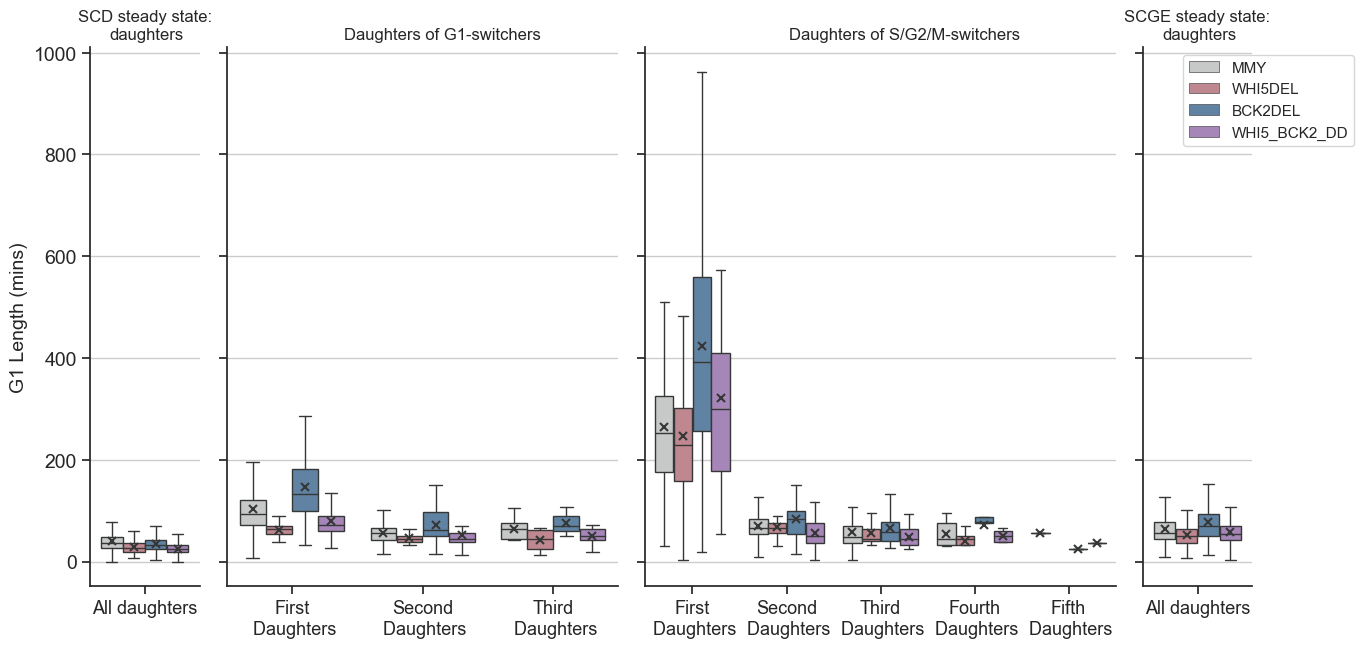

C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 21.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


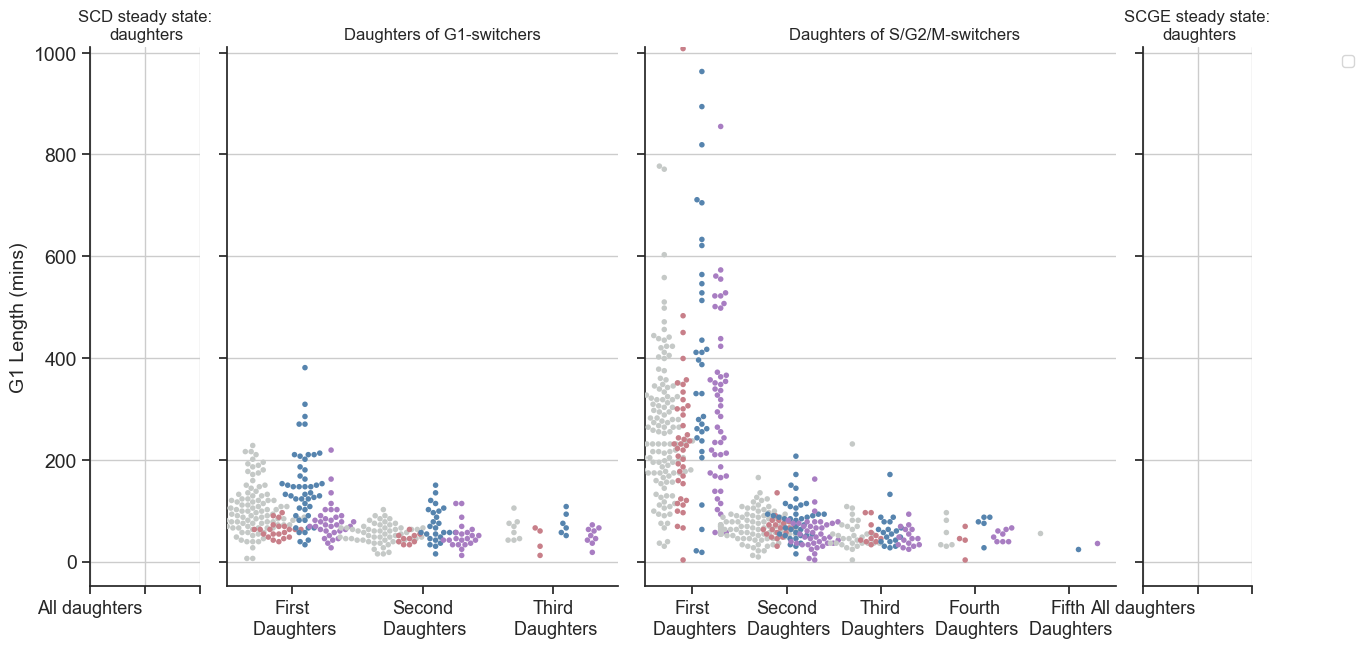

In [64]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2, ax3, ax4)) = plt.subplots(nrows=1, ncols=4, sharex= False, sharey= True, figsize=(15, 7), gridspec_kw={'width_ratios': [0.7,2.5, 3, 0.7]})
A, ((ax5, ax6, ax7, ax8)) = plt.subplots(nrows=1, ncols=4, sharex= False, sharey= True, figsize=(15, 7), gridspec_kw={'width_ratios': [0.7,2.5, 3, 0.7]})
S = sns.boxplot(data=(unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"]), 
                showmeans = True,
                x= "cell_cycle_stage", 
                y="time_in_stage_mins", 
                hue = "strain", 
                ax = ax1, 
                showfliers = False, 
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax1.set_title("SCD steady state: \ndaughters", fontsize = 12, x=0.52)
ax1.set_ylabel("G1 Length (mins)", fontsize = 14)

ax5.set_title("SCD steady state: \ndaughters", fontsize = 12, x=0.52)
ax5.set_ylabel("G1 Length (mins)", fontsize = 14)



S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"]),
                #order=['G1','S'],
                showmeans = True,
                x= "cell_cycle_stage",
                y="time_in_stage_mins",
                hue = "strain",
                ax = ax4,
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax4.set_title("SCGE steady state: \ndaughters", fontsize = 12, x=0.52)
ax4.set_ylabel("")
ax8.set_title("SCGE steady state: \ndaughters", fontsize = 12, x=0.52)
ax8.set_ylabel("")


S = sns.boxplot(data=unique_first_G1_frame_df_G1daughters,
                showmeans = True,
                x= "G1_switch_cells_daughter_wave",
                y="phase_length_mins",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
A = sns.swarmplot(data=unique_first_G1_frame_df_G1daughters, 
                       x= "G1_switch_cells_daughter_wave", y="phase_length_mins", ax = ax6, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                        palette = palette, dodge = True, size = 4)
ax2.set_title("Daughters of G1-switchers", fontsize = 12, x=0.55)
ax2.set_ylabel("")
ax6.set_title("Daughters of G1-switchers", fontsize = 12, x=0.55)
ax6.set_ylabel("")

S = sns.boxplot(data=unique_first_G1_frame_df_Sdaughters,
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_length_mins",
                ax = ax3,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
A = sns.swarmplot(data=unique_first_G1_frame_df_Sdaughters, 
                       x= "S_switch_cells_daughter_wave", y="phase_length_mins", ax = ax7, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                        palette = palette, dodge = True, size = 4)
ax3.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax3.set_ylabel("") 
ax7.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax7.set_ylabel("") 



ax1.legend([],[], frameon=False)
ax2.legend([],[], frameon=False)
ax3.legend([],[], frameon=False)
ax4.legend(loc='upper right', bbox_to_anchor=(2, 1))
ax5.legend([],[], frameon=False)
ax6.legend([],[], frameon=False)
ax7.legend([],[], frameon=False)
ax8.legend(loc='upper right', bbox_to_anchor=(2, 1))

# xtix = ['G1']
# ax1.set_xticklabels(xtix, fontsize = 14)
# ax2.set_xticklabels(xtix, fontsize = 14)
# ax3.set_xticklabels(xtix, fontsize = 14)
# ax4.set_xticklabels(xtix, fontsize = 14)


ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
ax2.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters'], fontsize = 13)
ax3.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters', 'Fifth\n Daughters'], fontsize = 13)
ax1.set_xticklabels(['All daughters'], fontsize = 13)
ax4.set_xticklabels(['All daughters'], fontsize = 13)

ax5.set_yticklabels(ax5.get_yticklabels(), fontsize = 14)
ax6.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax7.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters', 'Fifth\n Daughters'], fontsize = 13)
ax5.set_xticklabels(['All daughters'], fontsize = 13)
ax8.set_xticklabels(['All daughters'], fontsize = 13)

ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")
ax4.set_xlabel("")
ax5.set_xlabel("")
ax6.set_xlabel("")
ax7.set_xlabel("")
ax8.set_xlabel("")

S.figure.subplots_adjust(wspace = 0.1)
A.figure.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)
sns.despine(ax = ax5)
sns.despine(ax = ax6)
sns.despine(ax = ax7)
sns.despine(ax = ax8)

ax5.set_ylim(ax1.get_ylim())


# S.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig4\Panel2_daughtersofswitchers_G1_length.svg")
# A.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig4\Panel2_daughtersofswitchers_G1_length_swarm.svg")
plt.show()

# ***Fig 5B: statistics - selected strains*** 

In [65]:
from scipy import stats as scipystats
print("S-switchers first daughters stats:")
WT_df = unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "MMY") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
whi5del_df =  unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
bck2del_df = unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
whi5bck2dd_df =  unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_length_mins"]), (whi5del_df["phase_length_mins"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_length_mins"]), (bck2del_df["phase_length_mins"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_length_mins"]), (whi5bck2dd_df["phase_length_mins"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_length_mins"]), (bck2del_df["phase_length_mins"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_length_mins"]), (whi5del_df["phase_length_mins"]), equal_var = False))



S-switchers first daughters stats:
WT n 123
Bck2del n 34
whi5del n 40
whi5bck2dd n 50
WT VS WHI5 TtestResult(statistic=0.6126119958151159, pvalue=0.5425893873307591, df=56.534317931051866)
WT VS BCK2 TtestResult(statistic=-3.4539905469509224, pvalue=0.0013779423752692652, df=37.79023744176679)
WT VS DD TtestResult(statistic=-1.9079396342152497, pvalue=0.060676494315341306, df=67.14208691536041)
DD VS BCK2 TtestResult(statistic=-1.9180102379621669, pvalue=0.060013749005531185, df=58.27916529695645)
DD VS WHI5 TtestResult(statistic=1.9832269849571966, pvalue=0.050462019802750994, df=87.94474407517448)


# ***Fig 5C: Daughters of switchers - Vol at G1 end - selected strains*** 

In [66]:
############################### steady state dataprep ############################################################################
steady_state_df = SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == True) 
                              & (SS_SCDnSCGE['cell_cycle_stage'] == "G1")
                              & (SS_SCDnSCGE['Daughterhood_binary'] == 1)]

steady_state_plotting_df = steady_state_df[["f_pos_cell_id","time_in_stage_mins", "growthmedium", "strain", "Daughterhood_binary",
                                            "complete_phase", "sys_vol_at_frame_inc_G1_cells", "Birth_or_div_vol_fl", "frame_i", "lenG1_mins", "cell_cycle_stage"]]

# getting only the last frame of G1 for every cell
unique_f_pos_cell_id = []
for fposid in ((steady_state_plotting_df['f_pos_cell_id']).unique()):
    fposid_df = steady_state_plotting_df[steady_state_plotting_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id.append(phase_df.iloc[-1:])
unique_steady_state_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)

unique_steady_state_plotting_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df['strain'] == "MMY")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "BCK2DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5_BCK2_DD")
                                                                 ]



############################### nutrient switch SG2M daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

post_switch_Sdaughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)
                                                                                   ]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_Sdaughters = []
for fposid in ((post_switch_Sdaughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_Sdaughters_complete_G1_df[post_switch_Sdaughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_Sdaughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_Sdaughters = pd.concat(unique_f_pos_cell_id_Sdaughters).reset_index(drop = True)
unique_first_G1_frame_df_Sdaughters['phase_length_mins'] = unique_first_G1_frame_df_Sdaughters['phase_length']*3

############################### nutrient switch G1 daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

post_switch_G1daughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['G1_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)
                                                                                   ]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_G1daughters = []
for fposid in ((post_switch_G1daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_G1daughters_complete_G1_df[post_switch_G1daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_G1daughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_G1daughters = pd.concat(unique_f_pos_cell_id_G1daughters).reset_index(drop = True)
unique_first_G1_frame_df_G1daughters['phase_length_mins'] = unique_first_G1_frame_df_G1daughters['phase_length']*3





C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 19.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 15.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 38.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\1702812517.py:127: UserWarning: FixedFormatter should only be

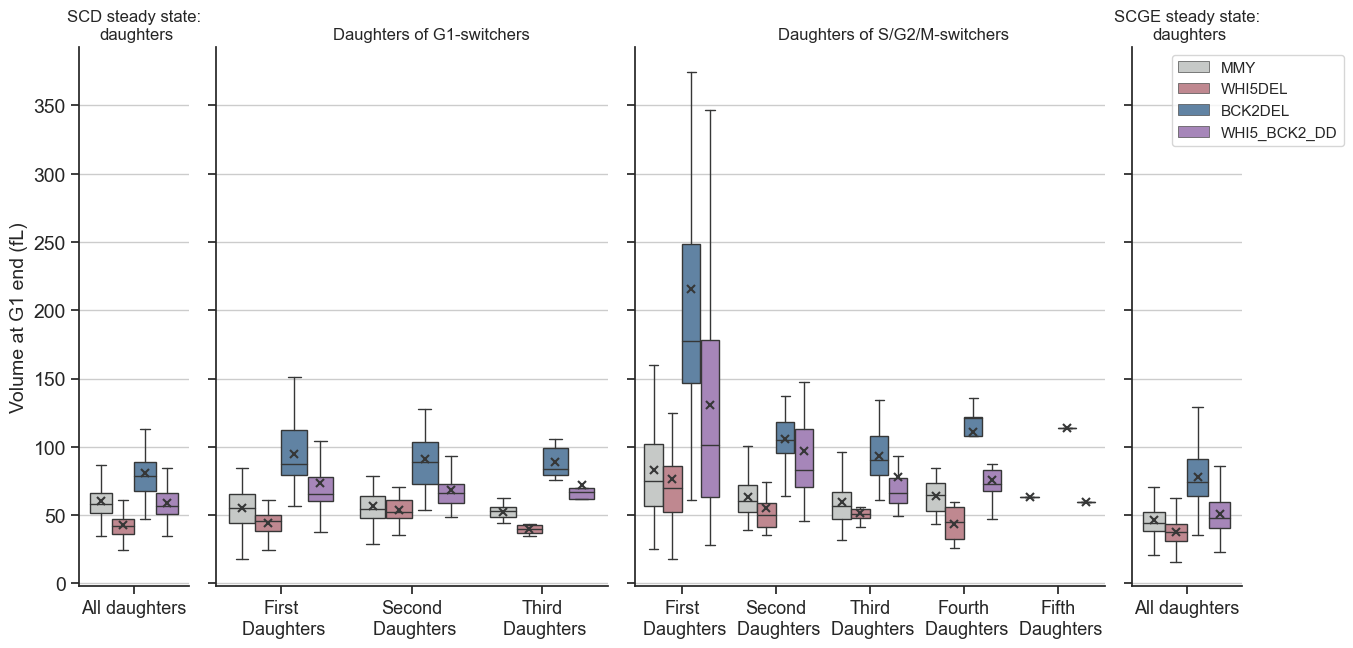

C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


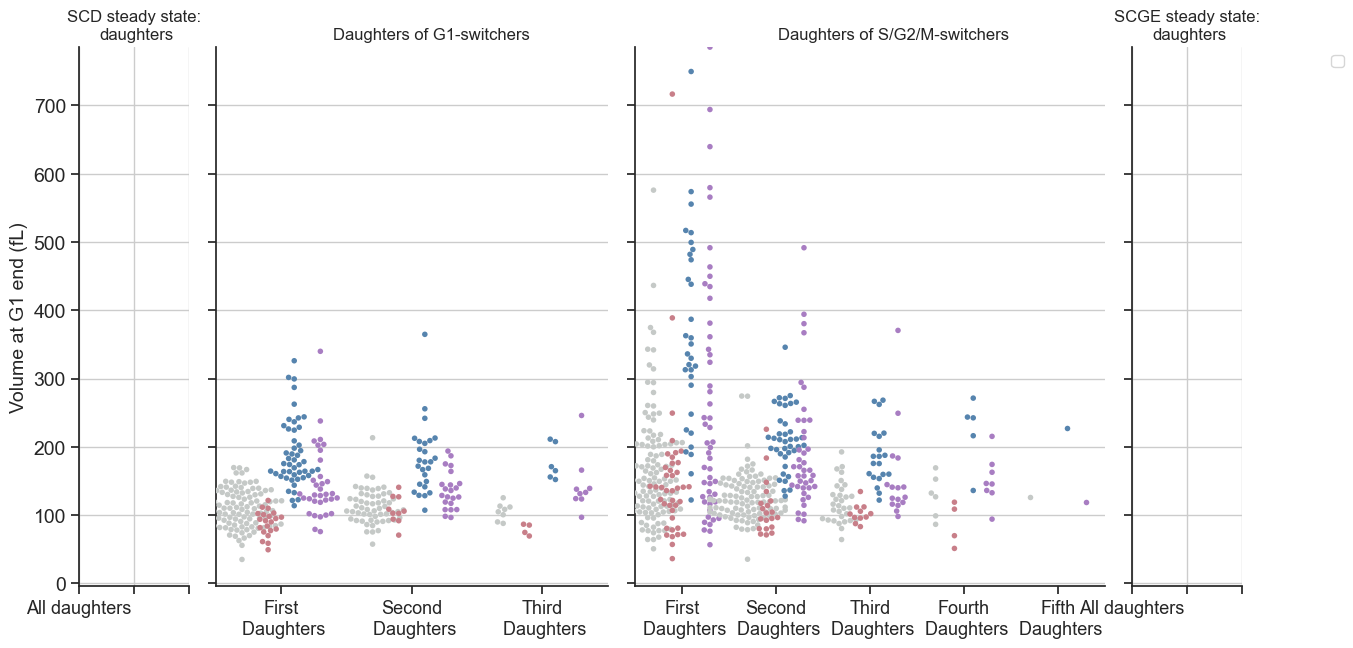

In [68]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2, ax3, ax4)) = plt.subplots(nrows=1, ncols=4, sharex= False, sharey= True, figsize=(15, 7), gridspec_kw={'width_ratios': [0.7,2.5, 3, 0.7]})
A, ((ax5, ax6, ax7, ax8)) = plt.subplots(nrows=1, ncols=4, sharex= False, sharey= True, figsize=(15, 7), gridspec_kw={'width_ratios': [0.7,2.5, 3, 0.7]})
S = sns.boxplot(data=(unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"]), 
                showmeans = True,
                x= "cell_cycle_stage", 
                y="sys_vol_at_frame_inc_G1_cells", 
                hue = "strain", 
                ax = ax1, 
                showfliers = False, 
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax1.set_title("SCD steady state: \ndaughters", fontsize = 12, x=0.52)
ax1.set_ylabel("Volume at G1 end (fL)", fontsize = 14)
ax5.set_title("SCD steady state: \ndaughters", fontsize = 12, x=0.52)
ax5.set_ylabel("Volume at G1 end (fL)", fontsize = 14)



S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"]),
                #order=['G1','S'],
                showmeans = True,
                x= "cell_cycle_stage",
                y="sys_vol_at_frame_inc_G1_cells",
                hue = "strain",
                ax = ax4,
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax4.set_title("SCGE steady state: \ndaughters", fontsize = 12, x=0.52)
ax4.set_ylabel("")
ax8.set_title("SCGE steady state: \ndaughters", fontsize = 12, x=0.52)
ax8.set_ylabel("")


S = sns.boxplot(data=unique_first_G1_frame_df_G1daughters,
                showmeans = True,
                x= "G1_switch_cells_daughter_wave",
                y="phase_volume_at_end",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
A = sns.swarmplot(data=unique_first_G1_frame_df_G1daughters, 
                       x= "G1_switch_cells_daughter_wave", y="phase_volume_at_end", ax = ax6, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                        palette = palette, dodge = True, size = 4)


ax2.set_title("Daughters of G1-switchers", fontsize = 12, x=0.55)
ax2.set_ylabel("")
ax6.set_title("Daughters of G1-switchers", fontsize = 12, x=0.55)
ax6.set_ylabel("")

S = sns.boxplot(data=unique_first_G1_frame_df_Sdaughters,
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_volume_at_end",
                ax = ax3,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
A = sns.swarmplot(data=unique_first_G1_frame_df_Sdaughters, 
                       x= "S_switch_cells_daughter_wave", y="phase_volume_at_end", ax = ax7, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                        palette = palette, dodge = True, size = 4)
ax3.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax3.set_ylabel("") 
ax7.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax7.set_ylabel("") 


ax1.legend([],[], frameon=False)
ax2.legend([],[], frameon=False)
ax3.legend([],[], frameon=False)
ax4.legend(loc='upper right', bbox_to_anchor=(2, 1))
ax5.legend([],[], frameon=False)
ax6.legend([],[], frameon=False)
ax7.legend([],[], frameon=False)
ax8.legend(loc='upper right', bbox_to_anchor=(2, 1))
# xtix = ['G1']
# ax1.set_xticklabels(xtix, fontsize = 14)
# ax2.set_xticklabels(xtix, fontsize = 14)
# ax3.set_xticklabels(xtix, fontsize = 14)
# ax4.set_xticklabels(xtix, fontsize = 14)


ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
ax2.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters'], fontsize = 13)
ax3.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters', 'Fifth\n Daughters'], fontsize = 13)
ax1.set_xticklabels(['All daughters'], fontsize = 13)
ax4.set_xticklabels(['All daughters'], fontsize = 13)

ax5.set_yticklabels(ax5.get_yticklabels(), fontsize = 14)
ax6.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax7.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters', 'Fifth\n Daughters'], fontsize = 13)
ax5.set_xticklabels(['All daughters'], fontsize = 13)
ax8.set_xticklabels(['All daughters'], fontsize = 13)

ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")
ax4.set_xlabel("")
ax5.set_xlabel("")
ax6.set_xlabel("")
ax7.set_xlabel("")
ax8.set_xlabel("")

S.figure.subplots_adjust(wspace = 0.1)
A.figure.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)
sns.despine(ax = ax5)
sns.despine(ax = ax6)
sns.despine(ax = ax7)
sns.despine(ax = ax8)
ax5.set_ylim(ax1.get_ylim())

# A.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig4\Panel3_daughtersofswitchers_volatG1end_swarm.svg")
#S.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig4\Panel3_daughtersofswitchers_volatG1end.svg")
plt.show()

# ***Fig 5C: statistics - selected strains*** 

In [69]:
from scipy import stats as scipystats
print("S-switchers first daughters stats:")
WT_df = unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "MMY") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
whi5del_df =  unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
bck2del_df = unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
whi5bck2dd_df =  unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_volume_at_end"]), (whi5del_df["phase_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_volume_at_end"]), (bck2del_df["phase_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_volume_at_end"]), (whi5bck2dd_df["phase_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_volume_at_end"]), (bck2del_df["phase_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_volume_at_end"]), (whi5del_df["phase_volume_at_end"]), equal_var = False))

print("G1-switchers first daughters stats:")
WT_df = unique_first_G1_frame_df_G1daughters[(unique_first_G1_frame_df_G1daughters["strain"] == "MMY") & (unique_first_G1_frame_df_G1daughters["G1_switch_cells_daughter_wave"] == 1)]
whi5del_df =  unique_first_G1_frame_df_G1daughters[(unique_first_G1_frame_df_G1daughters["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_G1daughters["G1_switch_cells_daughter_wave"] == 1)]
bck2del_df = unique_first_G1_frame_df_G1daughters[(unique_first_G1_frame_df_G1daughters["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_G1daughters["G1_switch_cells_daughter_wave"] == 1)]
whi5bck2dd_df =  unique_first_G1_frame_df_G1daughters[(unique_first_G1_frame_df_G1daughters["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_G1daughters["G1_switch_cells_daughter_wave"] == 1)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))

print("SCD steady state daughters")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))

print("SCGE steady state daughters")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))




S-switchers first daughters stats:
WT n 123
Bck2del n 34
whi5del n 40
whi5bck2dd n 50
WT VS WHI5 TtestResult(statistic=0.6910576377209107, pvalue=0.4925304410012181, df=53.260660352716926)
WT VS BCK2 TtestResult(statistic=-5.446889515442022, pvalue=4.3126657536661e-06, df=34.5212684009966)
WT VS DD TtestResult(statistic=-3.6133283994569703, pvalue=0.0006377268721360177, df=57.34641029782628)
DD VS BCK2 TtestResult(statistic=-3.1348568671599586, pvalue=0.0028507471632425447, df=51.00633854302823)
DD VS WHI5 TtestResult(statistic=3.5192609230044645, pvalue=0.0007046094408099218, df=83.17048444909689)
G1-switchers first daughters stats:
WT n 103
Bck2del n 48
whi5del n 21
whi5bck2dd n 33
SCD steady state daughters
WT n 198
Bck2del n 214
whi5del n 232
whi5bck2dd n 282
SCGE steady state daughters
WT n 330
Bck2del n 240
whi5del n 244
whi5bck2dd n 264


# ***Fig S4: Size control in daughters of S/G2/M switchers - selected strains*** 

In [70]:
#  calculating the diTalia metric: alpha*G1length 

In [71]:

######################################### filter for steady state cells with complete cycles only ##############################################

steady_state_completecycles_df =SS_SCDnSCGE[(SS_SCDnSCGE['complete_cycle'] == 1)
                                          & (SS_SCDnSCGE['relationship'] != "bud")
                                          & ((SS_SCDnSCGE['strain'] == "MMY")|
                                            (SS_SCDnSCGE['strain'] == "WHI5DEL")|
                                            (SS_SCDnSCGE['strain'] == "BCK2DEL")|
                                            (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD"))
                                           ]

# calculating alpha 
import warnings

with warnings.catch_warnings(record=True):
    for fposid in ((steady_state_completecycles_df['f_pos_cell_id']).unique()):
        selected_cell_df = steady_state_completecycles_df[steady_state_completecycles_df['f_pos_cell_id'] == fposid]
        selected_cell_df['ln_sys_vol_at_frame_inc_G1_cells'] = np.log(selected_cell_df['sys_vol_at_frame_inc_G1_cells'])
        slope, intercept, r_value, p_value, std_err = stats.linregress(selected_cell_df['frame_i'],selected_cell_df['ln_sys_vol_at_frame_inc_G1_cells'])
        SS_SCDnSCGE.loc[(SS_SCDnSCGE['f_pos_cell_id'] == fposid), 'alpha'] = slope



In [72]:

## filter for nutrient switch first and second daughter wave cells with complete cycles only ##############################################
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]
#display(selectedstrains_NS_plotting_df)
post_switch_daughters_df = selectedstrains_NS_plotting_df[((np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False)|
                                                        (np.isnan(selectedstrains_NS_plotting_df['G1_switch_cells_daughter_wave']) == False))
                                                      & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                        (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                      & (selectedstrains_NS_plotting_df['complete_cycle'] == 1)
                                                      ]

# calculating alpha 
import warnings

with warnings.catch_warnings(record=True):
    for fposid in ((post_switch_daughters_df['f_pos_cell_id']).unique()):
        selected_cell_df = post_switch_daughters_df[post_switch_daughters_df['f_pos_cell_id'] == fposid]
        selected_cell_df['ln_sys_vol_at_frame_inc_G1_cells'] = np.log(selected_cell_df['combined_mother_bud_volume'])
        slope, intercept, r_value, p_value, std_err = stats.linregress(selected_cell_df['frame_i'],selected_cell_df['ln_sys_vol_at_frame_inc_G1_cells'])
        selectedstrains_NS_plotting_df.loc[(selectedstrains_NS_plotting_df['f_pos_cell_id'] == fposid), 'alpha'] = slope
        
        

In [73]:

# calculate growth-rate standardised G1 length for each cell that has an alpha: (alpha*G1 length (mins)) - steady state

with warnings.catch_warnings(record=True):
    SS_SCDnSCGE['alpha_G1_length_frames'] = SS_SCDnSCGE['alpha']*SS_SCDnSCGE['len_G1']
    SS_SCDnSCGE['ln_birth_or_div_vol'] = np.log(SS_SCDnSCGE['Birth_or_div_vol_fl'])
    
# calculate growth-rate standardised G1 length for each cell that has an alpha: (alpha*G1 length (mins)) - nutrient switch

with warnings.catch_warnings(record=True):
    #selectedstrains_NS_plotting_df['phase_length_mins'] =  selectedstrains_NS_plotting_df['phase_length']*3
    selectedstrains_NS_plotting_df['alpha_phase_length_frames'] = (selectedstrains_NS_plotting_df['alpha'])*(selectedstrains_NS_plotting_df['phase_length'])
    selectedstrains_NS_plotting_df['ln_birth_or_div_vol'] = np.log(selectedstrains_NS_plotting_df['birth_or_div_vol'])
    
#palette ={"MMY": "grey", "WHI5DEL": "teal", "BCK2DEL": "mediumvioletred", "WHI5_BCK2_DD": "darkblue"}
   

In [74]:


###############################################  steadystate  #####################################################################

steadystate_completecycles_df = SS_SCDnSCGE[ (SS_SCDnSCGE['complete_phase'] == True) 
                                            & (SS_SCDnSCGE['Daughterhood_binary'] == 1)
                                           & ((SS_SCDnSCGE['strain'] == "MMY")|
                                            (SS_SCDnSCGE['strain'] == "WHI5DEL")|
                                            (SS_SCDnSCGE['strain'] == "BCK2DEL")|
                                            (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD"))]
SCD_steadystate_df = steadystate_completecycles_df[steadystate_completecycles_df['growthmedium'] == "SCD"]
SCGE_steadystate_df = steadystate_completecycles_df[steadystate_completecycles_df['growthmedium'] == "SCGE"]

#unique plotting df SCD
unique_f_pos_cell_id = []
for fposid in ((SCD_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCD_steadystate_df[SCD_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id.append(fposid_df.iloc[:1])
SCD_steadystate_daughters_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True) 
SCD_steadystate_daughters_plotting_df['plotting_col_ref'] = "SCD_SS"

#unique plotting df SCGE
unique_f_pos_cell_id_5 = []
for fposid in ((SCGE_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCGE_steadystate_df[SCGE_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_5.append(fposid_df.iloc[:1])
SCGE_steadystate_daughters_plotting_df = pd.concat(unique_f_pos_cell_id_5).reset_index(drop = True)
SCGE_steadystate_daughters_plotting_df['plotting_col_ref'] = "SCGE_SS"
            
##################################################  nutrient switch  ###################################################################

nutrientswitch_complete_wave_cycles_df =  selectedstrains_NS_plotting_df[((np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False))
                                                      & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                        (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                      & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                      & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                      ]


# unique plotting df nutrient switch 
unique_f_pos_cell_id_3 = []
for fposid in ((nutrientswitch_complete_wave_cycles_df['f_pos_cell_id']).unique()):
    fposid_df = nutrientswitch_complete_wave_cycles_df[nutrientswitch_complete_wave_cycles_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['birth_or_div_vol'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_3.append(fposid_df.iloc[:1])
nutrientswitch_daughterwaves_plotting_df = pd.concat(unique_f_pos_cell_id_3).reset_index(drop = True)
nutrientswitch_daughterwaves_plotting_df['alpha_G1_length_frames'] = nutrientswitch_daughterwaves_plotting_df['alpha_phase_length_frames']

for daughter_wave in nutrientswitch_daughterwaves_plotting_df['S_switch_cells_daughter_wave'].unique():
    nutrientswitch_daughterwaves_plotting_df.loc[(nutrientswitch_daughterwaves_plotting_df['S_switch_cells_daughter_wave'] == daughter_wave), 'plotting_col_ref'] = f'daughter_wave_{daughter_wave}'

figure_plotting_df = pd.concat([SCD_steadystate_daughters_plotting_df, SCGE_steadystate_daughters_plotting_df, nutrientswitch_daughterwaves_plotting_df]).reset_index(drop = True)


C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


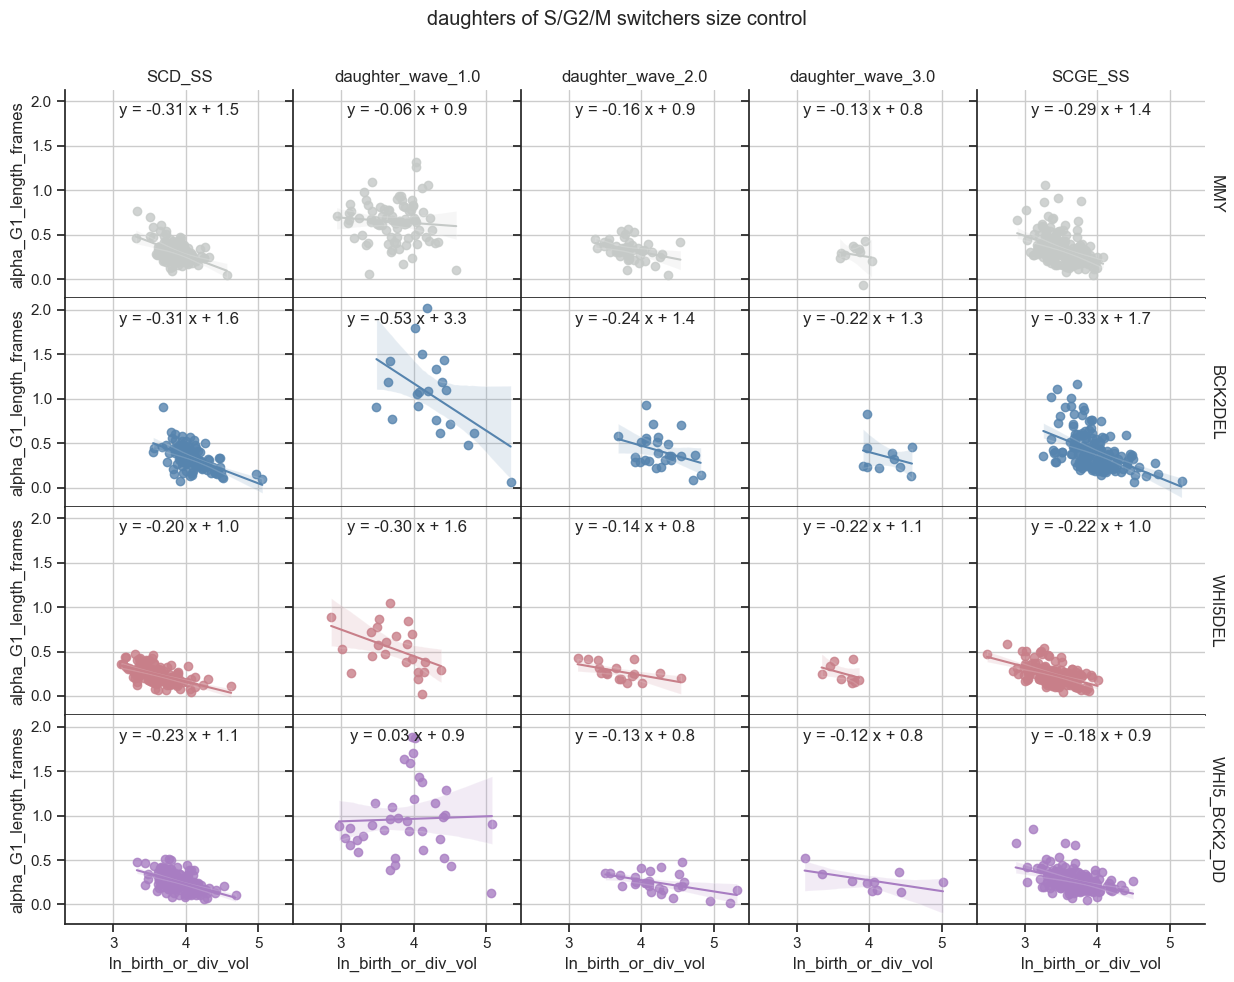

In [75]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

def annotate(data, **kws):
        ax = plt.gca()
        slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
        ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
                horizontalalignment='center',
                verticalalignment='center',
                transform=ax.transAxes)
        #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.FacetGrid(figure_plotting_df[(figure_plotting_df['plotting_col_ref'] != "daughter_wave_4.0") &
                                      (figure_plotting_df['plotting_col_ref'] != "daughter_wave_5.0")], 
                  col = "plotting_col_ref", 
                  col_order =['SCD_SS', 'daughter_wave_1.0', 'daughter_wave_2.0', 'daughter_wave_3.0', 'SCGE_SS'],
                  row = "strain", 
                  hue = "strain", 
                  palette = palette,
                  height = 2.5,
                  aspect  =1,
                  margin_titles = True)


b.map_dataframe(sns.regplot, 
      "ln_birth_or_div_vol",
      "alpha_G1_length_frames")


b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
b.fig.suptitle("daughters of S/G2/M switchers size control")
b.figure.subplots_adjust(wspace=0, hspace=0)
b.set()
# ax1.set_title("SCD steady state daughters")
# ax1.set_xlabel("ln(Birth volume)")
# ax1.set_ylabel("G1 Length*Growth Rate")
# ax1.set_ylim(-0.5,4)
# ax1.set_xlim(2,6)
#ax2.set_xscale("log")

#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\supplement\Fig5\panel1.svg", dpi =150)






plt.show()

# ***Fig 7B and 7C: Daughters of S/G2/M switchers - G1 length and vol at G1 end*** 

In [76]:

############################### nutrient switch SG2M daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_BCK2_TD")]

post_switch_Sdaughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_Sdaughters = []
for fposid in ((post_switch_Sdaughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_Sdaughters_complete_G1_df[post_switch_Sdaughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_Sdaughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_Sdaughters = pd.concat(unique_f_pos_cell_id_Sdaughters).reset_index(drop = True)


############################### pre-switch steady state dataprep ############################################################################

pre_switch_daughters_complete_G1_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['growthmedium'] == "SCD") 
                                                                    & (selectedstrains_NS_plotting_df['generation_num'] == 1)
                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                    & (selectedstrains_NS_plotting_df['phase_saw_switch'] == False)
                                                                    ]
# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_2 = []
for fposid in ((pre_switch_daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = pre_switch_daughters_complete_G1_df[pre_switch_daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_2.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_pre = pd.concat(unique_f_pos_cell_id_2).reset_index(drop = True)
unique_first_G1_frame_df_pre['S_switch_cells_daughter_wave'] = 0

preswitch_plus_postswitch = pd.concat([unique_first_G1_frame_df_Sdaughters, unique_first_G1_frame_df_pre])
preswitch_plus_postswitch['phase_length_mins'] = (preswitch_plus_postswitch['phase_length'])*3




C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 62.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 43.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 28.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 36.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yagya.chadha\.conda\env

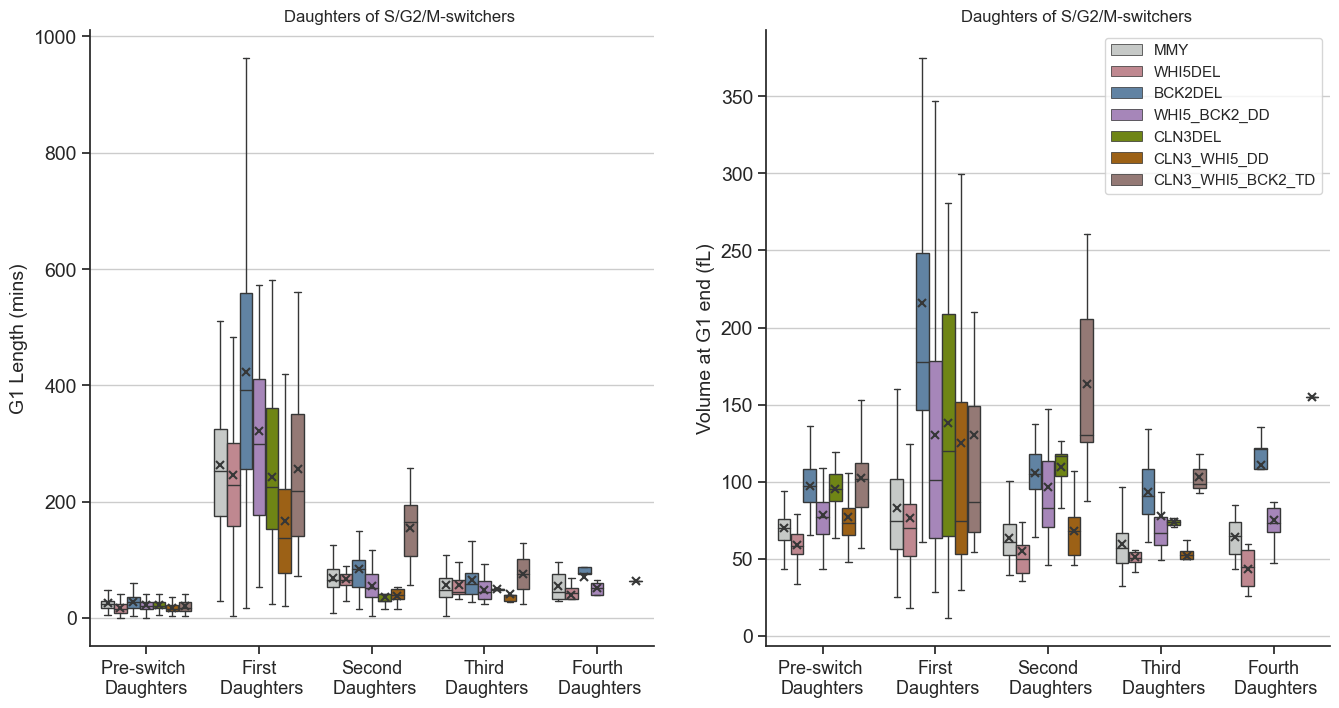

C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 31.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 16.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 22.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yagya.chadha\.conda\env

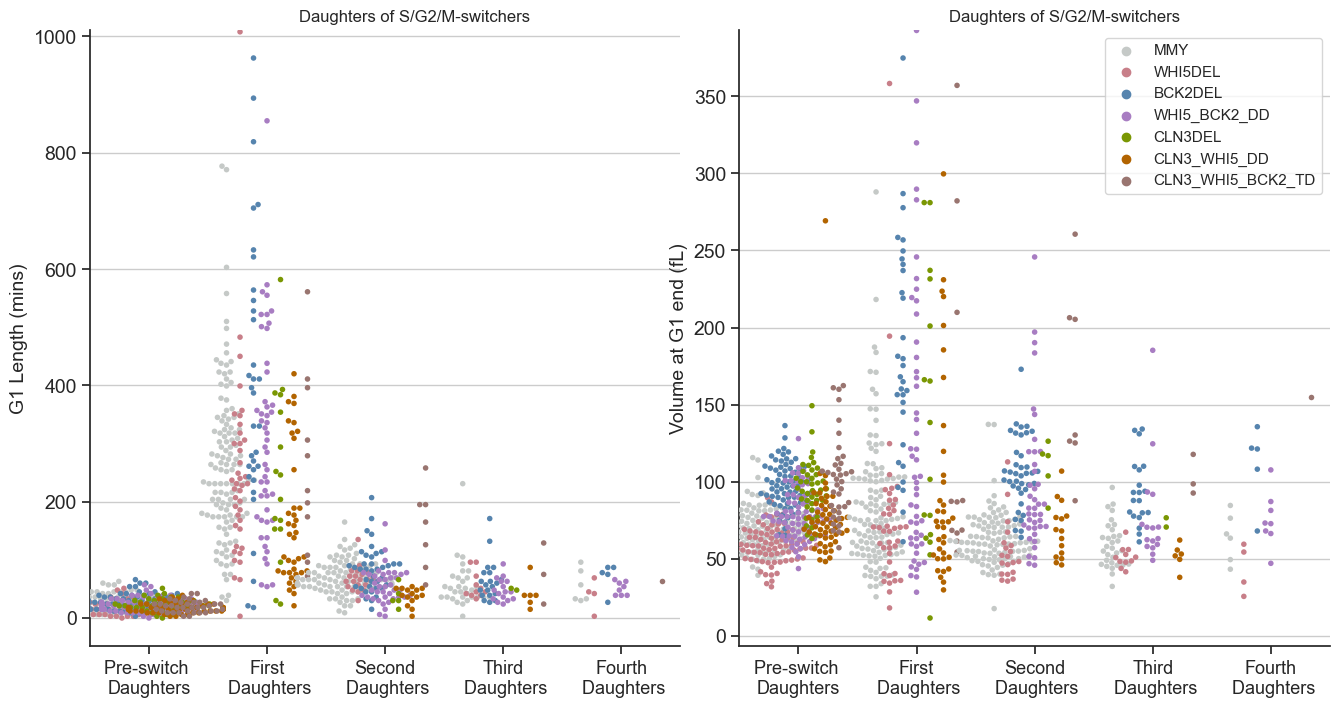

In [77]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", 
          "WHI5_BCK2_DD":"#a87dc2", "CLN3DEL": "#7a9703", "CLN3_WHI5_DD": "#b26400", "CLN3_WHI5_BCK2_TD": "#997570"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2)) = plt.subplots(nrows=1, ncols=2, sharex= True, sharey= False, figsize=(16, 8))
A, (ax3, ax4) = plt.subplots(nrows=1, ncols=2, sharex= True, sharey= False, figsize=(16, 8))



S = sns.boxplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5],
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_length_mins",
                ax = ax1,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
A = sns.swarmplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5], 
                       x= "S_switch_cells_daughter_wave", y="phase_length_mins", ax = ax3, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                        palette = palette, dodge = True, size = 4)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax2, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax1.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax1.set_ylabel("")
ax1.set_ylabel("G1 Length (mins)", fontsize = 14)

ax3.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax3.set_ylabel("")
ax3.set_ylabel("G1 Length (mins)", fontsize = 14)

S = sns.boxplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5],
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_volume_at_end",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)

A = sns.swarmplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5], 
                       x= "S_switch_cells_daughter_wave", y="phase_volume_at_end", ax = ax4, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                        palette = palette, dodge = True, size = 4)
# sns.swarmplot(x = "S_switch_cells_daughter_wave", y="phase_length_mins",
#                 ax = ax1, hue = "strain", data =preswitch_plus_postswitch, 
#               dodge = True, legend = False, edgecolor = "black", linewidth = 0.5, size = 3, color = 'black')
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax3, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax2.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax2.set_ylabel("Volume at G1 end (fL)", fontsize = 14) 
ax4.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax4.set_ylabel("Volume at G1 end (fL)", fontsize = 14) 


ax1.legend([],[], frameon=False)
ax2.legend(loc='upper right', bbox_to_anchor=(1, 1))
ax3.legend([],[], frameon=False)
ax4.legend(loc='upper right', bbox_to_anchor=(1, 1))
ax4.set_ylim(ax2.get_ylim())
ax3.set_ylim(ax1.get_ylim())
ax1.set_xlabel("") 
ax2.set_xlabel("") 
ax3.set_xlabel("") 
ax4.set_xlabel("") 
# xtix = ['G1']
# ax1.set_xticklabels(xtix, fontsize = 14)
# ax2.set_xticklabels(xtix, fontsize = 14)
# ax3.set_xticklabels(xtix, fontsize = 14)
# ax4.set_xticklabels(xtix, fontsize = 14)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize = 14)
ax3.set_yticklabels(ax3.get_yticklabels(), fontsize = 14)
ax4.set_yticklabels(ax4.get_yticklabels(), fontsize = 14)

ax1.set_xticklabels(['Pre-switch \nDaughters','First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax2.set_xticklabels(['Pre-switch \nDaughters','First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax3.set_xticklabels(['Pre-switch \nDaughters','First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax4.set_xticklabels(['Pre-switch \nDaughters','First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)

plt.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)



#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig7\Panel2_daughtersofSswitchers_G1_length_and_volatG1end.svg")
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig7\Panel2_daughtersofSswitchers_G1_length_and_volatG1end_swarm.svg")
plt.show()

In [78]:
print("S-switchers first daughters stats:")
cln3del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3DEL") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]
whi5cln3dd_df = preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_DD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]
whi5cln3bck2del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_BCK2_TD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]

print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

print("S-switchers second daughters stats:")
cln3del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3DEL") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 2)]
whi5cln3dd_df = preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_DD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 2)]
whi5cln3bck2del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_BCK2_TD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 2)]

print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

print("S-switchers third daughters stats:")
cln3del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3DEL") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 3)]
whi5cln3dd_df = preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_DD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 3)]
whi5cln3bck2del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_BCK2_TD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 3)]

print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

print("S-switchers fourth daughters stats:")
cln3del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3DEL") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 4)]
whi5cln3dd_df = preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_DD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 4)]
whi5cln3bck2del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_BCK2_TD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 4)]

print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

S-switchers first daughters stats:
cln3del n 16
whi5cln3dd n 39
whi5cln3bck2del n 11
S-switchers second daughters stats:
cln3del n 5
whi5cln3dd n 15
whi5cln3bck2del n 7
S-switchers third daughters stats:
cln3del n 2
whi5cln3dd n 6
whi5cln3bck2del n 3
S-switchers fourth daughters stats:
cln3del n 0
whi5cln3dd n 0
whi5cln3bck2del n 1


# ***Fig 7A: Birth volume pre-switch steady state cells*** 

In [79]:
############################### pre-switch steady state dataprep ############################################################################

pre_switch_complete_G1_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['growthmedium'] == "SCD")
                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                    & (selectedstrains_NS_plotting_df['phase_saw_switch'] == False)
                                                                    ]
# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_2 = []
for fposid in ((pre_switch_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = pre_switch_complete_G1_df[pre_switch_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_2.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_pre = pd.concat(unique_f_pos_cell_id_2).reset_index(drop = True)



C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\3054634126.py:40: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 17)


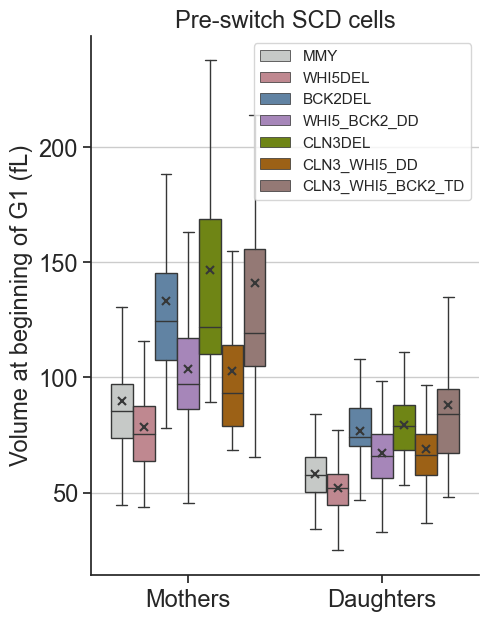

In [80]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", 
          "WHI5_BCK2_DD":"#a87dc2", "CLN3DEL": "#7a9703", "CLN3_WHI5_DD": "#b26400", "CLN3_WHI5_BCK2_TD": "#997570"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}

S, (ax1) = plt.subplots(nrows=1, ncols=1, sharex= False, sharey= True, figsize=(5, 7))


S = sns.boxplot(data=unique_first_G1_frame_df_pre,
                showmeans = True,
                x= "daughterhood_binary",
                y="cell_vol_fl",
                ax = ax1,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax2, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax1.set_title("Pre-switch SCD cells", fontsize = 17)
ax1.set_ylabel("")
ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax1.legend(loc='upper right', bbox_to_anchor=(1, 1))
ax1.set_xticklabels(['Mothers','Daughters'], fontsize = 17)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 17)
ax1.set_xlabel("")



# plt.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)



#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig7\Panel1_preswitchcells_vol_at_birth.svg")
plt.show()

In [81]:
print("pre-switch daughters stats:")
cln3del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
whi5cln3dd_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3_WHI5_DD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
whi5cln3bck2del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3_WHI5_BCK2_TD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
WT_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "MMY") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
whi5del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
bck2del_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
whi5bck2dd_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))
print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

print("pre-switch mothers stats:")
cln3del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
whi5cln3dd_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3_WHI5_DD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
whi5cln3bck2del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3_WHI5_BCK2_TD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
WT_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "MMY") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
whi5del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
bck2del_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
whi5bck2dd_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))
print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

pre-switch daughters stats:
WT n 164
Bck2del n 73
whi5del n 82
whi5bck2dd n 77
cln3del n 44
whi5cln3dd n 55
whi5cln3bck2del n 37
pre-switch mothers stats:
WT n 209
Bck2del n 95
whi5del n 87
whi5bck2dd n 95
cln3del n 48
whi5cln3dd n 61
whi5cln3bck2del n 34


# ***Fig S5: Death Analysis*** 

In [83]:
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_BCK2_TD")]

In [84]:
# add 'does_cell_die_in_experiment', 'does_cell_die_in_this_cycle' and 'does_cell_die_in_this_phase' to nutrient switch data
import warnings

with warnings.catch_warnings(record=True):
    
    list_for_joining = []
    i=0
    for rep in selectedstrains_NS_plotting_df['rep'].unique():
        rep_df = selectedstrains_NS_plotting_df[selectedstrains_NS_plotting_df['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df = rep_df[rep_df['strain'] == strain]
            for pos in (strain_df['position']).unique():
                pos_df = strain_df[strain_df["position"] == pos]
                pos_max_frame = pos_df['frame_i'].max()
                pos_min_frame = pos_df['frame_i'].min()
                for cell in (pos_df['Cell_ID']).unique():
                    cell_df = pos_df[pos_df["Cell_ID"] == cell]
                    
                    if sum(cell_df['is_cell_dead']) > 0:
                        cell_df['does_cell_die_in_experiment'] = 1
                        if strain == "MMY":
                            i=i+1
                    else:
                        cell_df['does_cell_die_in_experiment'] = 0
                    for cycle in (cell_df['generation_num']).unique(): 
                        cycle_df = cell_df[cell_df["generation_num"] == cycle]
                        cycle_df = cycle_df.sort_values(by = 'frame_i')
                        if sum(cycle_df['is_cell_dead']) > 0:
                            cycle_df['does_cell_die_in_this_cycle'] = 1
                        else:
                            cycle_df['does_cell_die_in_this_cycle'] = 0    
                        for phase in (cycle_df['cell_cycle_stage'].unique()):
                            phase_df = cycle_df[cycle_df['cell_cycle_stage'] == phase]
                            if ((phase_df['frame_i'].min()) > pos_min_frame) & ((phase_df['frame_i'].max()) < pos_max_frame):
                                phase_df['complete_phase'] = 1
                                phase_df['does_cell_die_in_this_phase'] = 0
                            if sum(phase_df['is_cell_dead']) > 0:
                                phase_df['complete_phase'] = 0
                                phase_df['does_cell_die_in_this_phase'] = 1
                            else:
                                phase_df['does_cell_die_in_this_phase'] = 0
                            list_for_joining.append(phase_df)
    plotting_df = pd.concat(list_for_joining)   

In [85]:
# add 'does_cell_die_in_experiment', 'does_cell_die_in_this_cycle' and 'does_cell_die_in_this_phase' to steady state data
import warnings

with warnings.catch_warnings(record=True):
    
    list_for_joining = []
    i=0
    for rep in SS_SCDnSCGE['rep'].unique():
        rep_df = SS_SCDnSCGE[SS_SCDnSCGE['rep'] == rep]
        for medium in rep_df['growthmedium'].unique():
            medium_df = rep_df[rep_df['growthmedium'] == medium]
            for strain in medium_df['strain'].unique():
                strain_df = medium_df[medium_df['strain'] == strain]
                for pos in (strain_df['position']).unique():
                    pos_df = strain_df[strain_df["position"] == pos]
                    pos_max_frame = pos_df['frame_i'].max()
                    pos_min_frame = pos_df['frame_i'].min()
                    for cell in (pos_df['Cell_ID']).unique():
                        cell_df = pos_df[pos_df["Cell_ID"] == cell]

                        if sum(cell_df['is_cell_dead']) > 0:
                            cell_df['does_cell_die_in_experiment'] = 1
                            if strain == "MMY":
                                i=i+1
                        else:
                            cell_df['does_cell_die_in_experiment'] = 0
                        for cycle in (cell_df['generation_num']).unique(): 
                            cycle_df = cell_df[cell_df["generation_num"] == cycle]
                            cycle_df = cycle_df.sort_values(by = 'frame_i')
                            if sum(cycle_df['is_cell_dead']) > 0:
                                cycle_df['does_cell_die_in_this_cycle'] = 1
                            else:
                                cycle_df['does_cell_die_in_this_cycle'] = 0    
                            for phase in (cycle_df['cell_cycle_stage'].unique()):
                                phase_df = cycle_df[cycle_df['cell_cycle_stage'] == phase]
                                if ((phase_df['frame_i'].min()) > pos_min_frame) & ((phase_df['frame_i'].max()) < pos_max_frame):
                                    phase_df['complete_phase'] = 1
                                    phase_df['does_cell_die_in_this_phase'] = 0
                                if sum(phase_df['is_cell_dead']) > 0:
                                    phase_df['complete_phase'] = 0
                                    phase_df['does_cell_die_in_this_phase'] = 1
                                else:
                                    phase_df['does_cell_die_in_this_phase'] = 0
                                list_for_joining.append(phase_df)
    steady_state_plotting_df = pd.concat(list_for_joining)  

In [86]:
# dataprep  steadystate  
# only keep complete cycles and cycles where cells died (drop cycles that are incomplete not due to dying but due to end or beginning of experiment)
steady_state_complete_plus_dead_cycles_df = steady_state_plotting_df.drop(steady_state_plotting_df[(steady_state_plotting_df['does_cell_die_in_this_cycle'] == 0) & (plotting_df['complete_cycle'] == 0)].index)

#select strains and split by media
steadystate_df = steady_state_complete_plus_dead_cycles_df[(steady_state_complete_plus_dead_cycles_df['strain'] == "MMY")|
                                            (steady_state_complete_plus_dead_cycles_df['strain'] == "WHI5DEL")|
                                            (steady_state_complete_plus_dead_cycles_df['strain'] == "BCK2DEL")|
                                            (steady_state_complete_plus_dead_cycles_df['strain'] == "WHI5_BCK2_DD")]
SCD_steadystate_df = steadystate_df[steadystate_df['growthmedium'] == "SCD"]
SCGE_steadystate_df = steadystate_df[steadystate_df['growthmedium'] == "SCGE"]

#get only first G1 frame for each cell-cycle SCD
unique_f_pos_cell_id = []
for fposid in ((SCD_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCD_steadystate_df[SCD_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id.append(fposid_df.iloc[:1])
SCD_steadystate_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True) 


#get only first G1 frame for each cell-cycle SCGE
unique_f_pos_cell_id_5 = []
for fposid in ((SCGE_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCGE_steadystate_df[SCGE_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_5.append(fposid_df.iloc[:1])
SCGE_steadystate_plotting_df = pd.concat(unique_f_pos_cell_id_5).reset_index(drop = True)


C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\1197686347.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  steady_state_complete_plus_dead_cycles_df = steady_state_plotting_df.drop(steady_state_plotting_df[(steady_state_plotting_df['does_cell_die_in_this_cycle'] == 0) & (plotting_df['complete_cycle'] == 0)].index)


In [87]:
# dataprep  nutrient switch  
# only keep complete cycles and cycles where cells died (drop cycles that are incomplete not due to dying but due to end or beginning of experiment)

complete_plus_dead_cycles_df = plotting_df.drop(plotting_df[(plotting_df['does_cell_die_in_this_cycle'] == 0) & (plotting_df['complete_cycle'] == 0)].index)

#get only first G1 frame for each cell cycle
first_frame_list = []
for cycle in complete_plus_dead_cycles_df.f_pos_cell_id.unique():
    cycle_df = complete_plus_dead_cycles_df[complete_plus_dead_cycles_df['f_pos_cell_id'] == cycle]
    first_frame_list.append(cycle_df.iloc[:1])
all_first_frame_df = pd.concat(first_frame_list).reset_index(drop = True)

# from nutrient switch data, drop cycles that were completed pre-switch because they do not reflect death in nutrient-switch conditions
first_frame_df = all_first_frame_df.drop(all_first_frame_df[(all_first_frame_df['growthmedium'] == "SCD") & (all_first_frame_df['cycle_saw_switch'] == False)].index)

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\1571854544.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2"], fontsize = 10)
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\1571854544.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax0.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2"], fontsize = 10)
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\1571854544.py:60: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_9448\1571854544.py:80: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax3.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10

Text(0.5, 0, '')

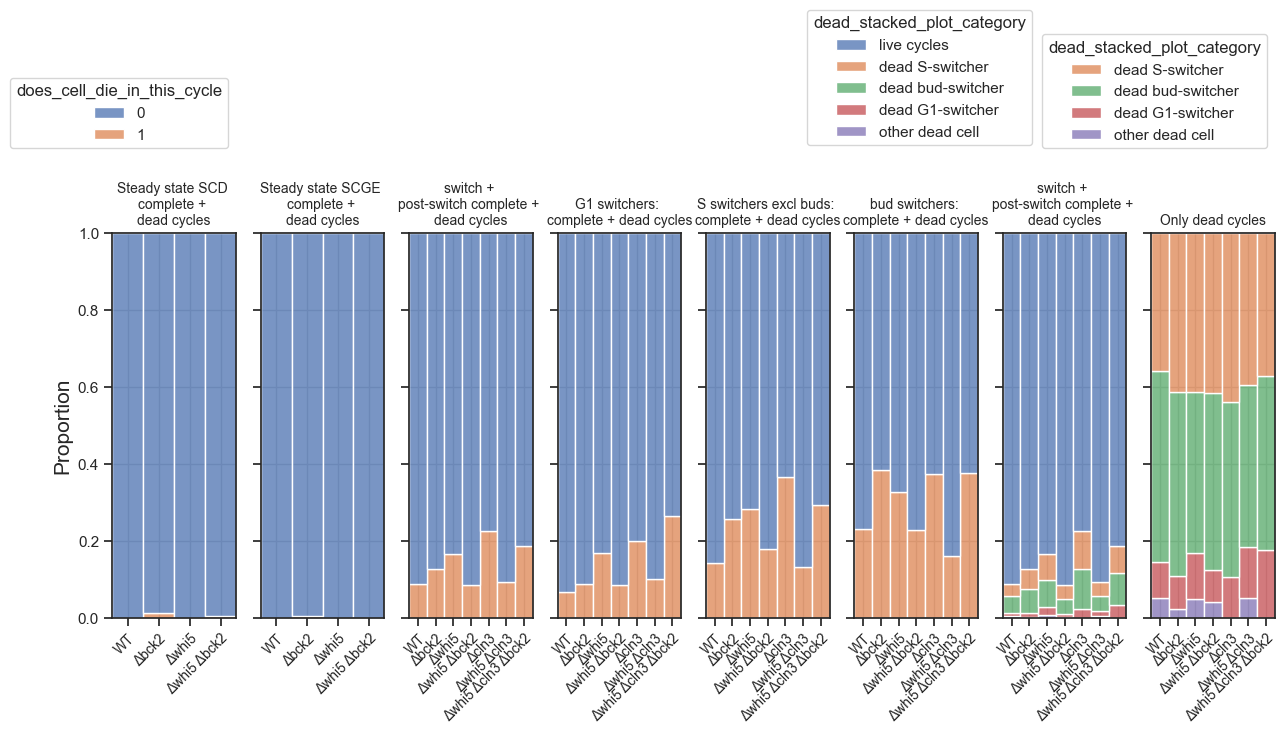

In [100]:
# plot
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

a, (ax1, ax0, ax2, ax3, ax4, ax5, ax6, ax7) = plt.subplots(nrows=1, ncols=8, sharex= False, sharey= True, figsize=(15, 5))

######### complete + dead cycles of steady state SCD cells #######################################################################
a = sns.histplot(data = SCD_steadystate_plotting_df, 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD"],
                 multiple = "fill", 
                 ax=ax1,
                 discrete = True)
sns.move_legend(ax1, "lower right", bbox_to_anchor=(1, 1.2))
#display(ax1.get_xticklabels())
ax1.set_title("Steady state SCD \ncomplete + \ndead cycles", fontsize = 10)
ax1.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax1.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2"], fontsize = 10)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax1.set_xlabel("")

######### complete + dead cycles of steady state SCGE cells #######################################################################
a = sns.histplot(data = SCGE_steadystate_plotting_df, 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD"],
                 multiple = "fill", 
                 ax=ax0,
                 discrete = True)
#sns.move_legend(ax0, "lower right", bbox_to_anchor=(1, 1.2))
#display(ax1.get_xticklabels())
ax0.set_title("Steady state SCGE \ncomplete + \ndead cycles", fontsize = 10)
ax0.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax0.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2"], fontsize = 10)
plt.setp(ax0.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax0.set_xlabel("")
######### complete + dead cycles of nutrient switch facing ro post-switch cells #######################################################################
a = sns.histplot(data = first_frame_df, 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax2,
                 discrete = True)
#sns.move_legend(ax2, "lower right", bbox_to_anchor=(1, 1.2))
#display(ax1.get_xticklabels())
ax2.set_title("switch + \npost-switch complete + \ndead cycles", fontsize = 10)
ax2.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax2.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax2.set_xlabel("")

######### complete + dead cycles of cells that saw switch in G1 #######################################################################
a = sns.histplot(data = first_frame_df[first_frame_df['cell_saw_switch_in_G1'] == True], 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax3,
                 discrete = True)
#sns.move_legend(ax1, "lower right", bbox_to_anchor=(3, 1))
#display(ax1.get_xticklabels())
ax3.set_title("G1 switchers: \ncomplete + dead cycles", fontsize = 10)
ax3.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax3.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax3.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax3.set_xlabel("")

######### complete + dead cycles of cells that saw switch in S excl buds #######################################################################
a = sns.histplot(data = first_frame_df[(first_frame_df['cell_saw_switch_in_S'] == True) & (first_frame_df['cell_saw_switch_as_bud'] == False)], 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax4,
                 discrete = True)
#sns.move_legend(ax1, "lower right", bbox_to_anchor=(3, 1))
#display(ax1.get_xticklabels())
ax4.set_title("S switchers excl buds: \ncomplete + dead cycles", fontsize = 10)
ax4.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax4.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax4.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax4.set_xlabel("")

######### complete + dead cycles of cells that saw switch as buds #######################################################################
a = sns.histplot(data = first_frame_df[(first_frame_df['cell_saw_switch_in_S'] == True) & (first_frame_df['cell_saw_switch_as_bud'] == True)], 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax5,
                 discrete = True)
#sns.move_legend(ax1, "lower right", bbox_to_anchor=(3, 1))
#display(ax1.get_xticklabels())
ax5.set_title("bud switchers: \ncomplete + dead cycles", fontsize = 10)
ax5.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax5.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax5.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax5.set_xlabel("")
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == 1), 'dead_stacked_plot_category'] = "other dead cell"
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == 1) & 
                   (first_frame_df['cell_saw_switch_in_S'] == True) & 
                   (first_frame_df['cell_saw_switch_as_bud'] == True), 'dead_stacked_plot_category'] = "dead bud-switcher"
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == 1) & 
                   (first_frame_df['cell_saw_switch_in_S'] == True) & 
                   (first_frame_df['cell_saw_switch_as_bud'] == False), 'dead_stacked_plot_category'] = "dead S-switcher"
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == 1) & 
                   (first_frame_df['cell_saw_switch_in_G1'] == True), 'dead_stacked_plot_category'] = "dead G1-switcher"
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == False), 'dead_stacked_plot_category'] = "live cycles"

######### complete + dead cycles of ALL CELLS #######################################################################


a = sns.histplot(data = first_frame_df, 
                 hue = "dead_stacked_plot_category", 
                 x = "strain", 
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax6,
                 discrete = True)
sns.move_legend(ax6, "upper right", bbox_to_anchor=(0.3, 1.6))
#display(ax1.get_xticklabels())
ax6.set_title("switch + \npost-switch complete + \ndead cycles", fontsize = 10)
ax6.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax6.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax6.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax6.set_xlabel("")

######### dead cycles of ALL CELLS #######################################################################
palette = ['#dd8452','#55a868', '#c44e52', '#8172b3']
a = sns.histplot(data = first_frame_df[first_frame_df['does_cell_die_in_this_cycle'] == 1], 
                 hue = "dead_stacked_plot_category", 
                 x = "strain", 
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax7,
                 palette=palette,
                 discrete = True)
sns.move_legend(ax7, "lower right", bbox_to_anchor=(1, 1.2))
#display(ax1.get_xticklabels())
ax7.set_title("Only dead cycles", fontsize = 10)
ax7.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax7.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax7.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax7.set_xlabel("")
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig7\Panel3_death_analysis_updated_150724.svg", bbox_inches = 'tight')

In [ ]:
# colours and labels were edited further in inkscape

# ***Fig 3A: Calculating total number of complete cycles for paper*** 

In [101]:
#nutrient-switch data (selected strains only)
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_BCK2_TD")
                                                                    ]
complete_cycles = selectedstrains_NS_plotting_df[selectedstrains_NS_plotting_df['complete_cycle'] == 1]
pos_len= 0
complete_cycle_length =len(complete_cycles.f_pos_cell_id.unique())
for rep in ((complete_cycles['rep']).unique()):
    rep_df = complete_cycles[complete_cycles['rep'] == rep]
    for strain in ((rep_df['strain']).unique()):
        strain_df = rep_df[rep_df['strain'] == strain]
        pos_len =pos_len + len(strain_df.position.unique())

display("number of complete cycles (nutrient switch data only):", complete_cycle_length)
display("number of positions (nutrient switch data only):", pos_len)

#for selected strains in steady-state, add no of positions and complete cell cycles to what was calculated for nutrient switch above
complete_cycles = SS_SCDnSCGE[SS_SCDnSCGE['complete_cycle'] == 1]
for rep in ((complete_cycles['rep']).unique()):
    rep_df = complete_cycles[complete_cycles['rep'] == rep]
    for medium in ((rep_df['growthmedium']).unique()):
        medium_df = rep_df[rep_df['growthmedium'] == medium]
        for strain in ((medium_df['strain']).unique()):
            strain_df = medium_df[medium_df['strain'] == strain]
            if ((strain == "CCR4DEL") | 
                (strain == "WHI5_CCR4_DD")) & (medium == "SCGE"):
                pass
            else:
                pos_len =pos_len + len(strain_df.position.unique())
                complete_cycle_length =complete_cycle_length + len(strain_df.f_pos_cell_id.unique())
display("total positions", pos_len)
display("total complete cycles", complete_cycle_length)


'number of complete cycles (nutrient switch data only):'

6226

'number of positions (nutrient switch data only):'

149

'total positions'

269

'total complete cycles'

9219

In [102]:
# add to this the complete cycles and position numbers from cell cycle marker experiment for the number shown in Fig 3A